# **CAPSTONE (EDA)**

**Setup**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, confusion_matrix
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

import xgboost as xgb
import shap

sns.set(style="whitegrid")

**Loading...**

In [ ]:
train_df = pd.read_csv('/content/fraudTrain.csv')
test_df = pd.read_csv('/content/fraudTest.csv', on_bad_lines='skip')

# Combine first for chronological engineering
df = pd.concat([train_df, test_df], ignore_index=True)

# Convert datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Sort chronologically
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

print(df.shape)
df.head()

(1852394, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
# DATASET STATISTICS

total = len(df)
fraud = df['is_fraud'].sum()
legit = total - fraud

print("Total:", total)
print("Fraud:", fraud)
print("Legit:", legit)
print("Fraud %:", fraud / total)

Total: 1852394
Fraud: 9651
Legit: 1842743
Fraud %: 0.005210014716091717


In [ ]:
for col in df.select_dtypes(include=['float64']):
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include=['int64']):
    df[col] = df[col].astype('int32')

**Data Understanding (EDA)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def format_boxplot(ax):
    ax.grid(False)

    sns.despine(
        ax=ax,
        top=True,
        right=True,
        left=False,
        bottom=False
    )

    plt.tight_layout()

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Unnamed: 0             int32         
 1   trans_date_trans_time  datetime64[ns]
 2   cc_num                 int32         
 3   merchant               object        
 4   category               object        
 5   amt                    float32       
 6   first                  object        
 7   last                   object        
 8   gender                 object        
 9   street                 object        
 10  city                   object        
 11  state                  object        
 12  zip                    int32         
 13  lat                    float32       
 14  long                   float32       
 15  city_pop               int32         
 16  job                    object        
 17  dob                    object        
 18  trans_num             

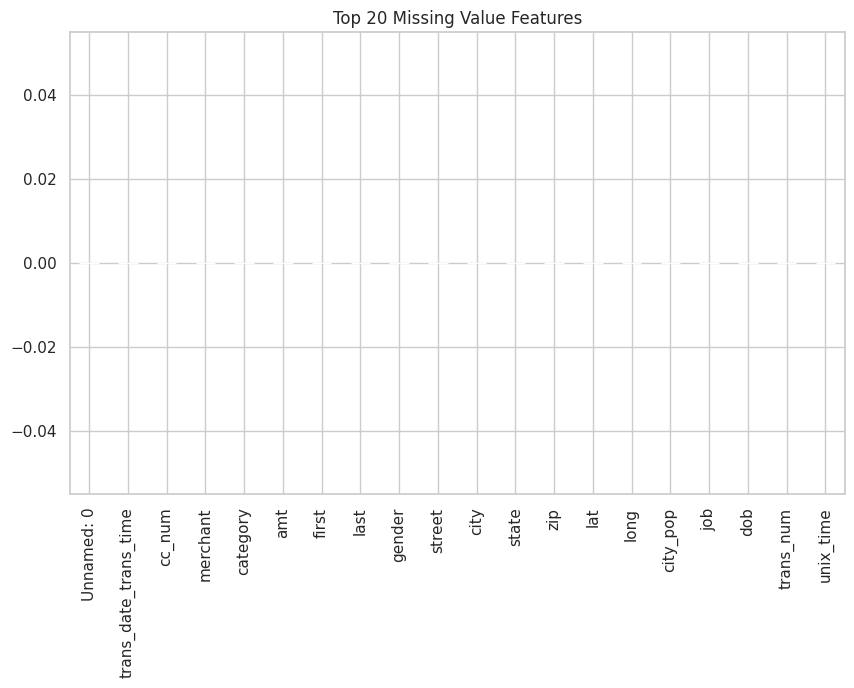

In [ ]:
missing = df.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing.head(20).plot(kind='bar')
plt.title("Top 20 Missing Value Features")
plt.show()

/tmp/ipykernel_464/4115025698.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_464/4115025698.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


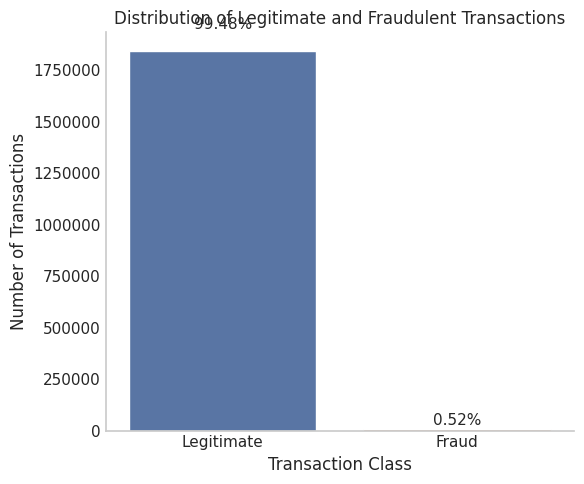

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x='is_fraud',
    data=df,
    palette=['#4C72B0', '#DD8452']
)

plt.title(
    'Distribution of Legitimate and Fraudulent Transactions'
)

plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')

ax.set_xticklabels([
    'Legitimate',
    'Fraud'
])

# ------------------------------------------
# Remove gridlines
# ------------------------------------------

ax.grid(False)

# ------------------------------------------
# Remove scientific notation (1e6)
# ------------------------------------------

formatter = ScalarFormatter(useMathText=False)
formatter.set_scientific(False)
formatter.set_useOffset(False)
ax.yaxis.set_major_formatter(formatter)

# ------------------------------------------
# Remove top and right borders only
# ------------------------------------------

sns.despine()

# ------------------------------------------
# Percentage labels
# ------------------------------------------

total = len(df)

for p in ax.patches:

    count = p.get_height()
    pct = count / total * 100
    offset = max(total * 0.002, count * 0.05)

    ax.annotate(
        f'{pct:.2f}%',
        (
            p.get_x() + p.get_width()/2,
            count + offset
        ),
        ha='center',
        va='bottom',
        fontsize=11
    )

# ------------------------------------------
# Remove tick marks
# ------------------------------------------

ax.tick_params(axis='both', length=0)

plt.tight_layout()

plt.show()

In [ ]:
counts = df['is_fraud'].value_counts()
print(counts)
print(counts / len(df))

is_fraud
0    1842743
1       9651
Name: count, dtype: int64
is_fraud
0    0.99479
1    0.00521
Name: count, dtype: float64


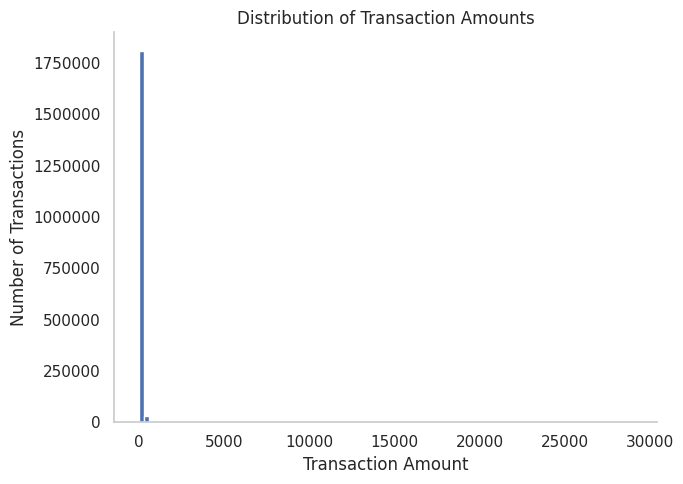

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(7,5))

ax = plt.gca()

plt.hist(
    df['amt'],
    bins=100,
    color='#4C72B0'
)

plt.title(
    'Distribution of Transaction Amounts'
)

plt.xlabel(
    'Transaction Amount'
)

plt.ylabel(
    'Number of Transactions'
)

# Remove gridlines
ax.grid(False)

# Remove scientific notation
formatter = ScalarFormatter(useMathText=False)
formatter.set_scientific(False)
formatter.set_useOffset(False)
ax.yaxis.set_major_formatter(formatter)

# Remove top/right borders
sns.despine()

plt.tight_layout()

plt.show()

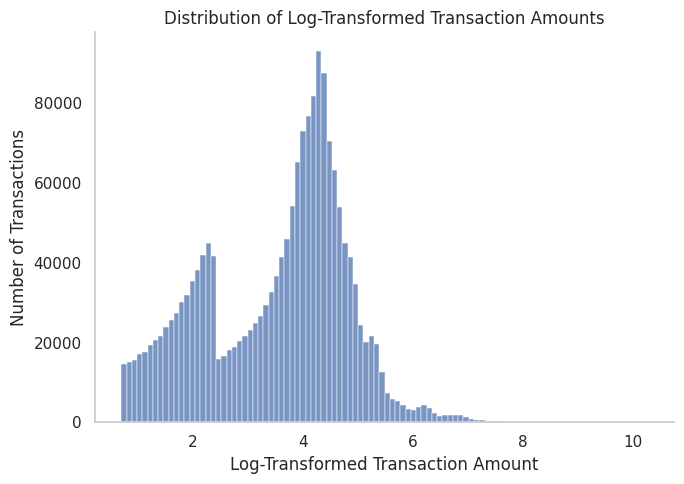

In [ ]:
df['log_amt'] = np.log1p(df['amt'])

plt.figure(figsize=(7,5))

ax = plt.gca()

sns.histplot(
    df['log_amt'],
    bins=100,
    color='#4C72B0'
)

plt.title(
    'Distribution of Log-Transformed Transaction Amounts'
)

plt.xlabel(
    'Log-Transformed Transaction Amount'
)

plt.ylabel(
    'Number of Transactions'
)

# Remove gridlines
ax.grid(False)

# Remove top/right borders
sns.despine()

plt.tight_layout()

plt.show()

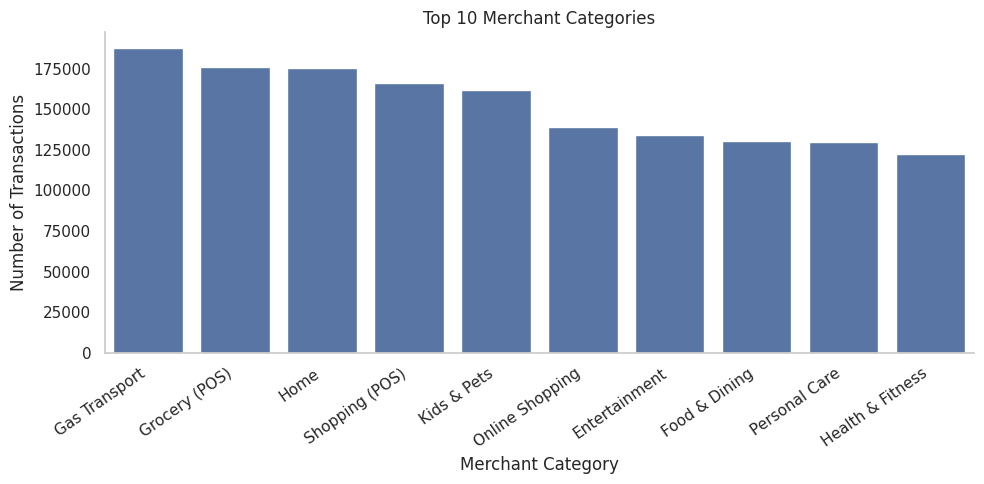

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_categories = (
    df["category"]
    .value_counts()
    .head(10)
)

category_labels = [
    "Gas Transport",
    "Grocery (POS)",
    "Home",
    "Shopping (POS)",
    "Kids & Pets",
    "Online Shopping",
    "Entertainment",
    "Food & Dining",
    "Personal Care",
    "Health & Fitness"
]

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=category_labels,
    y=top_categories.values,
    color="#4C72B0"
)

plt.title("Top 10 Merchant Categories")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=35, ha="right")

format_boxplot(ax)

plt.show()

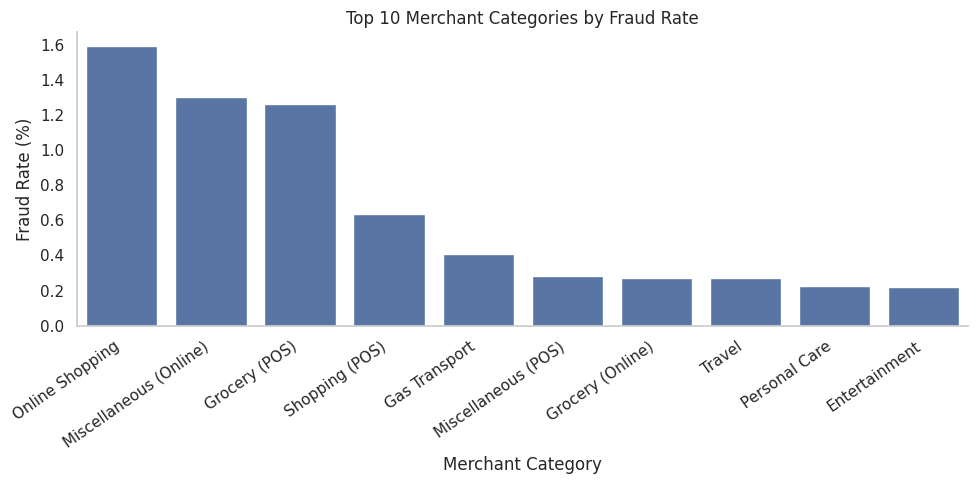

In [ ]:
fraud_by_cat = (
    df.groupby("category")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .head(10)
)

label_map = {
    "shopping_net": "Online Shopping",
    "misc_net": "Miscellaneous (Online)",
    "grocery_pos": "Grocery (POS)",
    "shopping_pos": "Shopping (POS)",
    "gas_transport": "Gas Transport",
    "misc_pos": "Miscellaneous (POS)",
    "grocery_net": "Grocery (Online)",
    "travel": "Travel",
    "personal_care": "Personal Care",
    "entertainment": "Entertainment"
}

labels = [
    label_map[x]
    for x in fraud_by_cat.index
]

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=labels,
    y=fraud_by_cat.values,
    color="#4C72B0"
)

plt.title("Top 10 Merchant Categories by Fraud Rate")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=35, ha="right")

format_boxplot(ax)

plt.show()

**Feature Review**

In [ ]:
missing = df.isnull().mean().sort_values(ascending=False)
missing.head(20)

,0
Unnamed: 0,0.0
trans_date_trans_time,0.0
cc_num,0.0
merchant,0.0
category,0.0
amt,0.0
first,0.0
last,0.0
gender,0.0
street,0.0


**Feature Engineering**

Historical Feature Engineering

Customer-level behavioral features were computed using only transactions available prior to the transaction being evaluated. This approach prevents information leakage and more closely reflects a real-world fraud detection scenario.

In [ ]:
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

# TEMPORAL FEATURES
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = df['hour'].isin([0,1,2,3,4,22,23]).astype(int)

# TRANSACTION GAP FEATURES
df = df.sort_values(['cc_num', 'trans_date_trans_time'])

df['time_since_last_txn'] = (
    df.groupby('cc_num')['trans_date_trans_time']
    .diff()
    .dt.total_seconds()
)

df['time_since_last_txn'] = df['time_since_last_txn'].fillna(0)

# HISTORICAL SPENDING FEATURES

df['avg_amt_per_card'] = (
    df.groupby('cc_num')['amt']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['avg_amt_per_card'] = (
    df['avg_amt_per_card']
    .fillna(df['amt'].median())
)

df['std_amt_per_card'] = (
    df.groupby('cc_num')['amt']
      .expanding()
      .std()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['std_amt_per_card'] = (
    df['std_amt_per_card']
    .fillna(0)
)

df['amt_deviation'] = (
    df['amt']
    -
    df['avg_amt_per_card']
)

df['amt_ratio'] = (
    df['amt']
    /
    (df['avg_amt_per_card'] + 1)
)

df['amt_zscore'] = (
    (df['amt'] - df['avg_amt_per_card'])
    /
    (df['std_amt_per_card'] + 1)
)

# FREQUENCY FEATURES
df['tx_count_per_card'] = (
    df.groupby('cc_num')
      .cumcount()
)

def expanding_unique_count_series(series):
    unique_elements = set()
    counts = []
    for item in series:
        unique_elements.add(item)
        counts.append(len(unique_elements))
    return pd.Series(counts, index=series.index)

# Calculate expanding unique merchants per card
df['unique_merchants_per_card'] = (
    df.groupby('cc_num')['merchant']
      .apply(expanding_unique_count_series)
      .reset_index(level=0, drop=True)
)

# MERCHANT FEATURES
df['historical_merchant_freq'] = (
    df.groupby('merchant')
      .cumcount()
)

# GEOGRAPHIC FEATURES

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat/2)**2
        + cos(lat1)
        * cos(lat2)
        * sin(dlon/2)**2
    )

    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

df['distance_from_home'] = df.apply(
    lambda x: haversine(
        x['lat'],
        x['long'],
        x['merch_lat'],
        x['merch_long']
    ),
    axis=1
)

print("Feature engineering completed")

Feature engineering completed


In [ ]:
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

# ADDITIONAL BEHAVIORAL FEATURES

# Transaction Date
df['txn_date'] = df['trans_date_trans_time'].dt.date

# Transaction Month
df['txn_month'] = df['trans_date_trans_time'].dt.to_period('M')

# Days Since Last Transaction
df['days_since_last_txn'] = (
    df['time_since_last_txn'] /
    (60 * 60 * 24)
)

df['hours_since_last_txn'] = (
    df['time_since_last_txn']
    / 3600
)

df['avg_time_since_last_txn'] = (
    df.groupby('cc_num')['hours_since_last_txn']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['avg_time_since_last_txn'] = (
    df['avg_time_since_last_txn']
    .fillna(0)
)

df['avg_days_since_last_txn'] = (
    df.groupby('cc_num')['days_since_last_txn']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['avg_days_since_last_txn'] = (
    df['avg_days_since_last_txn']
    .fillna(0)
)

# Daily Transaction Count
df['daily_txn_count'] = (
    df.groupby(
        ['cc_num','txn_date']
    )
    .cumcount()
)

# Unique Merchants (for categories in this context)
def expanding_unique_count(series):
    seen = set()
    counts = []
    for item in series:
        seen.add(item)
        counts.append(
            len(seen)
        )
    return pd.Series(
        counts,
        index=series.index
    )

df['daily_count_unique_categories_per_card'] = (
    df.groupby(
        ['cc_num','txn_date']
    )['category']
    .apply(
        expanding_unique_count
    )
    .reset_index(
        level=[0,1],
        drop=True
    )
)

df['daily_count_unique_merchants_per_card'] = (
    df.groupby(
        ['cc_num','txn_date']
    )['merchant']
    .apply(
        expanding_unique_count
    )
    .reset_index(
        level=[0,1],
        drop=True
    )
)

# Monthly Transaction Count
df['monthly_txn_count'] = (
    df.groupby(
        ['cc_num','txn_month']
    )
    .cumcount()
)

# DAILY SPENDING (HISTORICAL ONLY)
df['daily_total_amt'] = (
    df.groupby(['cc_num','txn_date'])['amt']
      .transform(lambda x: x.cumsum().shift(1))
      .fillna(0)
)

df['daily_total_amt'] = df['daily_total_amt'].fillna(0)

df['historical_daily_avg'] = (
    df.groupby('cc_num')['daily_total_amt']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['historical_daily_avg'] = (
    df['historical_daily_avg']
    .fillna(
        df['daily_total_amt'].median()
    )
)

df['daily_spend_ratio'] = (
    df['daily_total_amt']
    /
    (df['historical_daily_avg'] + 1)
)

# MONTHLY SPENDING (HISTORICAL ONLY)
df['monthly_total_amt'] = (
    df.groupby(['cc_num','txn_month'])['amt']
      .transform(lambda x: x.cumsum().shift(1))
      .fillna(0)
)

df['monthly_total_amt'] = (
    df['monthly_total_amt']
      .fillna(0)
)

df['historical_monthly_avg'] = (
    df.groupby('cc_num')['monthly_total_amt']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['historical_monthly_avg'] = (
    df['historical_monthly_avg']
    .fillna(
        df['monthly_total_amt'].median()
    )
)

df['monthly_spend_ratio'] = (
    df['monthly_total_amt']
    /
    (df['historical_monthly_avg'] + 1)
)

print("Advanced behavioral features completed")

Advanced behavioral features completed


**Outlier Trial**

In [ ]:
outlier_cols = [
    'amt',
    'amt_ratio',
    'amt_deviation',
    'amt_zscore',
    'daily_total_amt',
    'monthly_total_amt',
    'daily_spend_ratio',
    'monthly_spend_ratio',
    'time_since_last_txn'
]

for col in outlier_cols:
    print(f"\n===== {col} =====")
    print(
        df[col].describe(
            percentiles=[0.01, 0.05, 0.95, 0.99]
        )
    )


===== amt =====
count    1.852394e+06
mean     7.006355e+01
std      1.589949e+02
min      1.000000e+00
1%       1.260000e+00
5%       2.440000e+00
50%      4.745000e+01
95%      1.953400e+02
99%      5.379000e+02
max      2.894890e+04
Name: amt, dtype: float64

===== amt_ratio =====
count    1.852394e+06
mean     9.974845e-01
std      2.511892e+00
min      1.905626e-03
1%       1.895105e-02
5%       3.698500e-02
50%      6.585914e-01
95%      2.623230e+00
99%      7.162088e+00
max      4.780266e+02
Name: amt_ratio, dtype: float64

===== amt_deviation =====
count    1.852394e+06
mean    -2.513612e-01
std      1.585636e+02
min     -1.430420e+03
1%      -8.838188e+01
5%      -7.336737e+01
50%     -2.413231e+01
95%      1.173188e+02
99%      4.510970e+02
max      2.888934e+04
Name: amt_deviation, dtype: float64

===== amt_zscore =====
count    1.852394e+06
mean     2.679425e-02
std      5.054328e+00
min     -1.430420e+03
1%      -8.562696e-01
5%      -6.692547e-01
50%     -1.850637e-01
9

In [ ]:
winsor_cols = [
    'amt_ratio',
    'amt_zscore',
    'daily_spend_ratio',
    'monthly_spend_ratio'
]

for col in winsor_cols:

    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(
        lower=lower,
        upper=upper
    )

print("Winsorization completed")

Winsorization completed


In [ ]:
sample_card = df['cc_num'].iloc[0]

cols = [
    'trans_date_trans_time',
    'amt',
    'daily_total_amt',
    'monthly_total_amt',
    'daily_txn_count',
    'monthly_txn_count'
]

print(
    df[df['cc_num'] == sample_card][cols]
      .head(15)
)

      trans_date_trans_time         amt  daily_total_amt  monthly_total_amt  \
269     2019-01-01 03:27:51  158.490005         0.000000           0.000000   
8014    2019-01-06 05:18:43   56.910000         0.000000         158.490005   
9960    2019-01-07 03:24:01   43.619999         0.000000         215.400009   
10599   2019-01-07 11:52:21   97.730003        43.619999         259.020020   
11260   2019-01-07 17:11:20    8.190000       141.350006         356.750031   
13856   2019-01-08 19:19:42    5.820000         0.000000         364.940033   
14985   2019-01-09 14:10:40    2.830000         0.000000         370.760040   
16548   2019-01-10 19:52:40    1.120000         0.000000         373.590027   
19348   2019-01-12 18:47:15   76.720001         0.000000         374.710022   
25514   2019-01-15 16:08:47   17.000000         0.000000         451.430023   
25921   2019-01-15 19:26:26   43.360001        17.000000         468.430023   
28220   2019-01-17 12:43:36    1.160000         0.00

Dummies

In [ ]:
# ONE-HOT ENCODING

category_dummies = pd.get_dummies(
    df["category"],
    prefix="cat"
)

hour_dummies = pd.get_dummies(
    df["hour"],
    prefix="hour",
    dtype=int
)

dow_dummies = pd.get_dummies(
    df["day_of_week"],
    prefix="dow",
    dtype=int
)

month_dummies = pd.get_dummies(
    df["month"],
    prefix="month",
    dtype=int
)

df = pd.concat(
    [
        df,
        category_dummies,
        hour_dummies,
        dow_dummies,
        month_dummies
    ],
    axis=1
)

In [ ]:
# Remove original categorical columns
df = df.drop(
    columns=[
        "category",
        "hour",
        "day_of_week",
        "month"
    ]
)

print("One-hot encoding completed.")

One-hot encoding completed.


**Feature Validation**

In [ ]:
feature_validation = df.groupby('is_fraud')[[
    'amt_deviation',
    'amt_ratio',
    'amt_zscore',
    'time_since_last_txn',
    'days_since_last_txn',
    'daily_txn_count',
    'monthly_txn_count',
    'daily_total_amt',
    'monthly_total_amt',
    'daily_spend_ratio',
    'monthly_spend_ratio',
    'distance_from_home'
]].mean()

feature_validation

,amt_deviation,amt_ratio,amt_zscore,time_since_last_txn,days_since_last_txn,daily_txn_count,monthly_txn_count,daily_total_amt,monthly_total_amt,daily_spend_ratio,monthly_spend_ratio,distance_from_home
is_fraud,,,,,,,,,,,,
0,-2.435426,0.892381,-0.037106,30975.143830,0.358509,2.114983,58.793887,150.055679,4079.905518,1.045942,1.184929,76.110969
1,416.769594,4.415355,2.279131,20927.338203,0.242215,2.530101,40.578593,1185.637085,4793.808594,5.057768,2.190887,76.256232


/tmp/ipykernel_464/3106284128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/3106284128.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


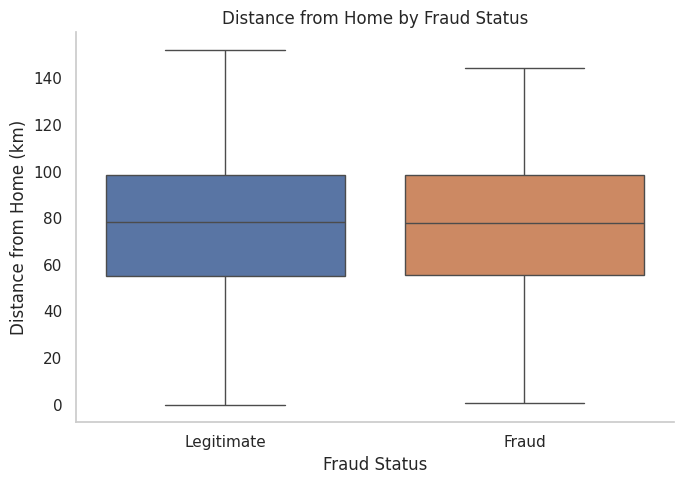

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="distance_from_home",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.title(
    "Distance from Home by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Distance from Home (km)")

format_boxplot(ax)

plt.show()

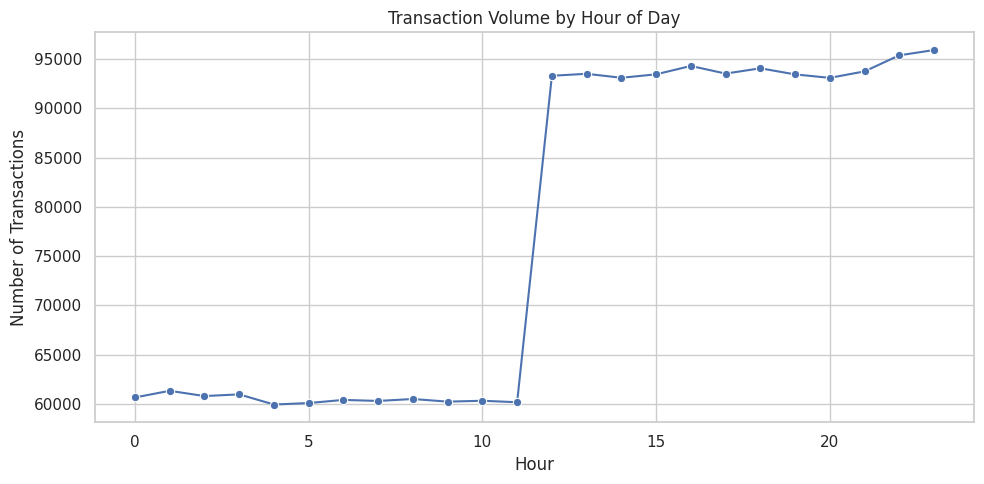

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['hour'] = df['trans_date_trans_time'].dt.hour

hourly_txns = (
    df.groupby('hour')
      .size()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_txns.index,
    y=hourly_txns.values,
    marker='o'
)

plt.title('Transaction Volume by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

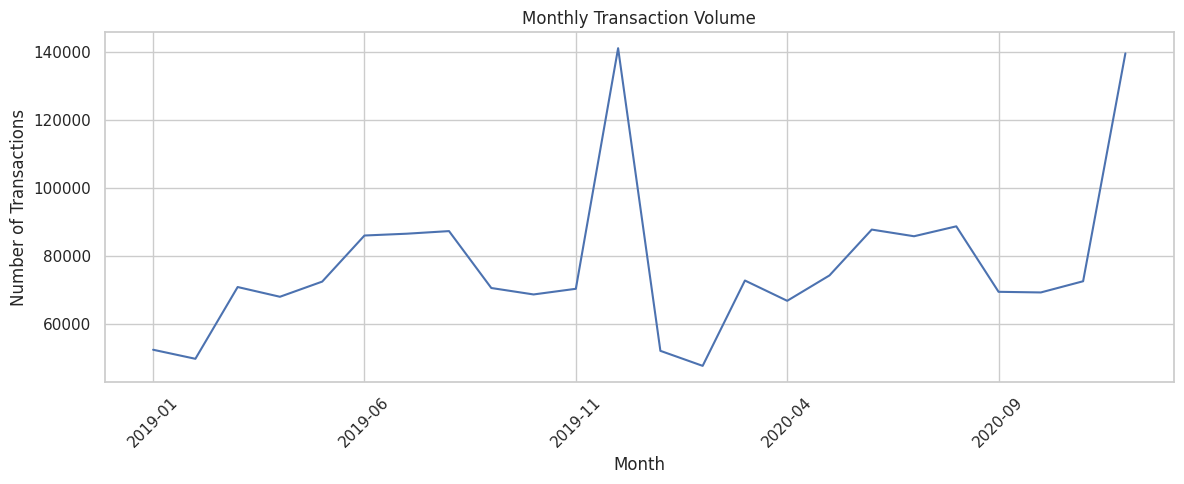

In [ ]:
import matplotlib.pyplot as plt

monthly_txns = (
    df.groupby(
        df['trans_date_trans_time']
          .dt.to_period('M')
    )
    .size()
)

monthly_txns.index = monthly_txns.index.astype(str)

plt.figure(figsize=(12,5))

monthly_txns.plot()

plt.title('Monthly Transaction Volume')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Daily/Monthly Spend Ratio**
- Customer Level

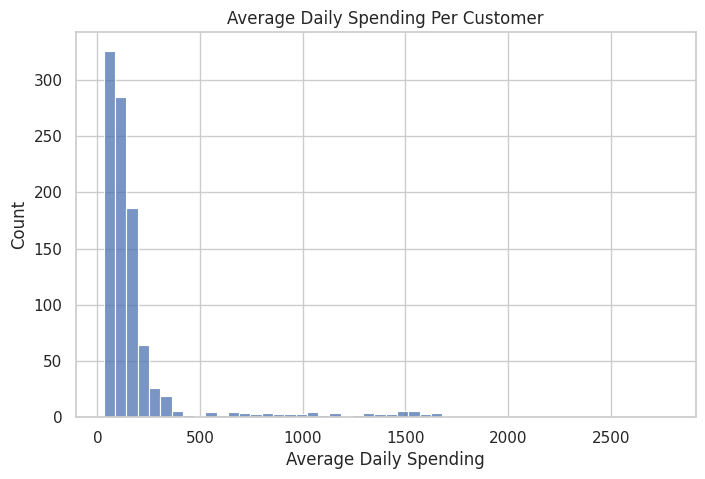

In [ ]:
customer_daily_spend = (
    df.groupby('cc_num')['daily_total_amt']
      .mean()
)

plt.figure(figsize=(8,5))

sns.histplot(
    customer_daily_spend,
    bins=50
)

plt.title(
    'Average Daily Spending Per Customer'
)

plt.xlabel(
    'Average Daily Spending'
)

plt.show()

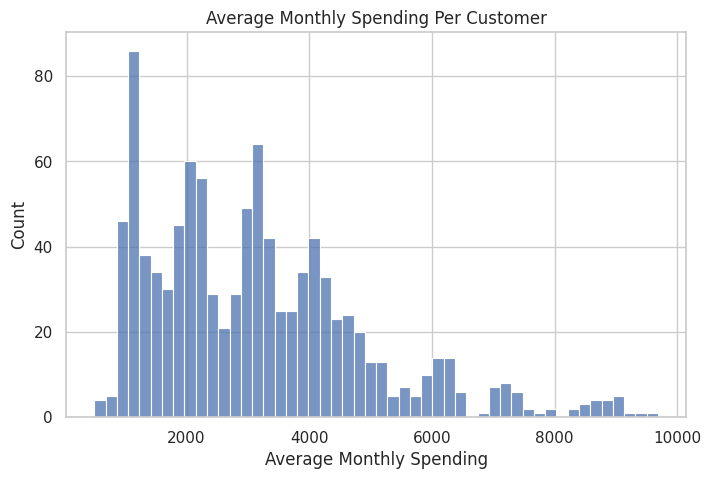

In [ ]:
customer_monthly_spend = (
    df.groupby('cc_num')['monthly_total_amt']
      .mean()
)

plt.figure(figsize=(8,5))

sns.histplot(
    customer_monthly_spend,
    bins=50
)

plt.title(
    'Average Monthly Spending Per Customer'
)

plt.xlabel(
    'Average Monthly Spending'
)

plt.show()

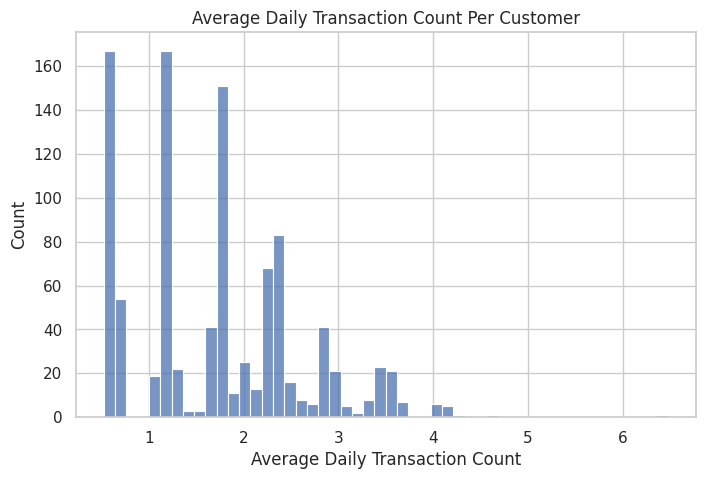

In [ ]:
customer_daily_txn = (
    df.groupby('cc_num')['daily_txn_count']
      .mean()
)

plt.figure(figsize=(8,5))

sns.histplot(
    customer_daily_txn,
    bins=50
)

plt.title(
    'Average Daily Transaction Count Per Customer'
)

plt.xlabel(
    'Average Daily Transaction Count'
)

plt.show()

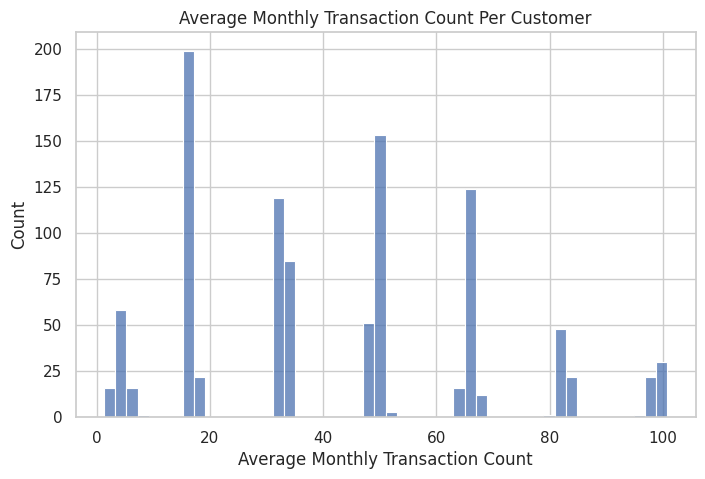

In [ ]:
customer_monthly_txn = (
    df.groupby('cc_num')['monthly_txn_count']
      .mean()
)

plt.figure(figsize=(8,5))

sns.histplot(
    customer_monthly_txn,
    bins=50
)

plt.title(
    'Average Monthly Transaction Count Per Customer'
)

plt.xlabel(
    'Average Monthly Transaction Count'
)

plt.show()

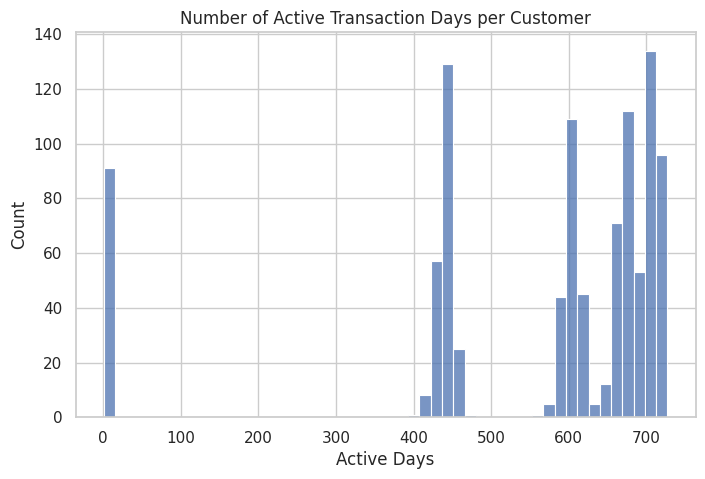

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_daily_days,
    bins=50
)

plt.title(
    'Number of Active Transaction Days per Customer'
)

plt.xlabel(
    'Active Days'
)

plt.show()

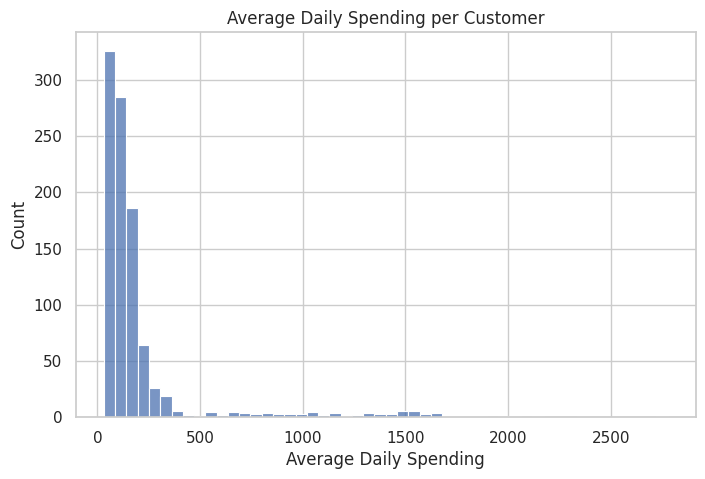

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_daily_avg,
    bins=50
)

plt.title(
    'Average Daily Spending per Customer'
)

plt.xlabel(
    'Average Daily Spending'
)

plt.show()

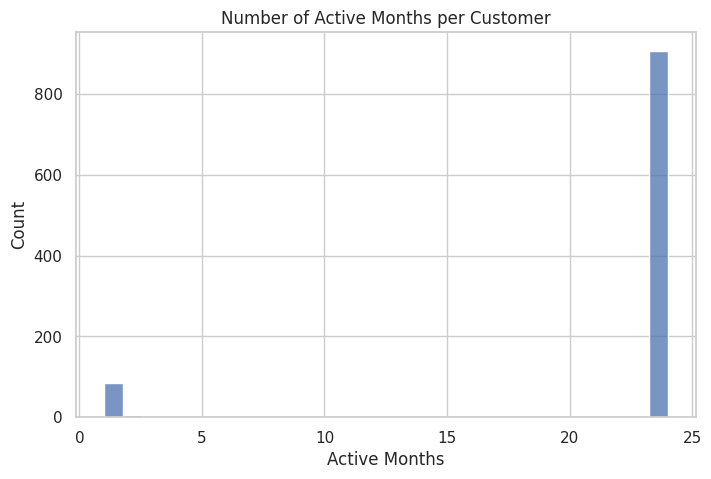

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_active_months,
    bins=30
)

plt.title(
    'Number of Active Months per Customer'
)

plt.xlabel(
    'Active Months'
)

plt.show()

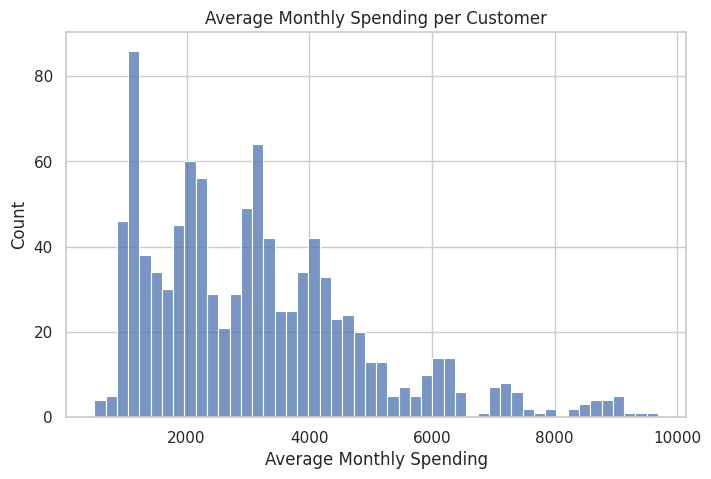

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_monthly_avg,
    bins=50
)

plt.title(
    'Average Monthly Spending per Customer'
)

plt.xlabel(
    'Average Monthly Spending'
)

plt.show()

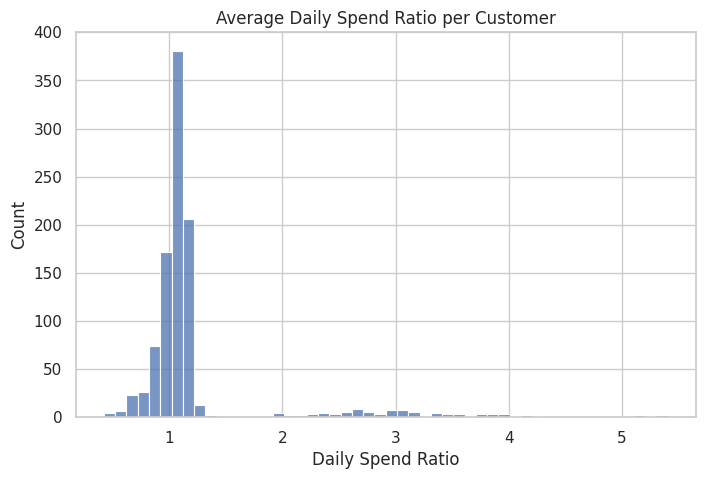

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_daily_ratio,
    bins=50
)

plt.title(
    'Average Daily Spend Ratio per Customer'
)

plt.xlabel(
    'Daily Spend Ratio'
)

plt.show()

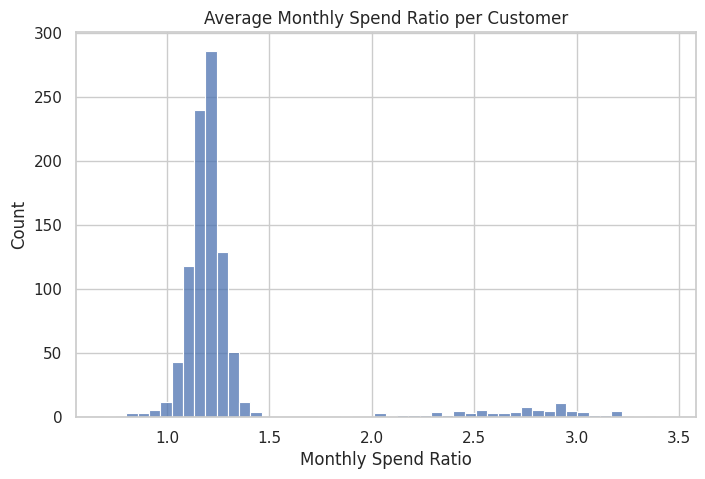

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_monthly_ratio,
    bins=50
)

plt.title(
    'Average Monthly Spend Ratio per Customer'
)

plt.xlabel(
    'Monthly Spend Ratio'
)

plt.show()

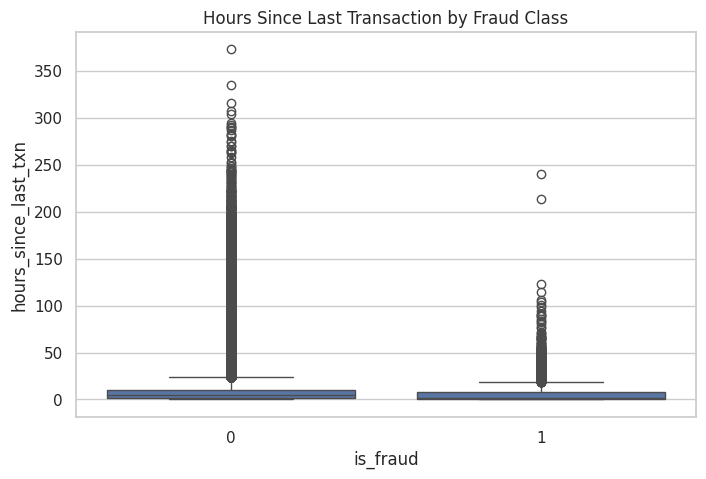

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='hours_since_last_txn',
    data=df
)

plt.title(
    'Hours Since Last Transaction by Fraud Class'
)

plt.show()

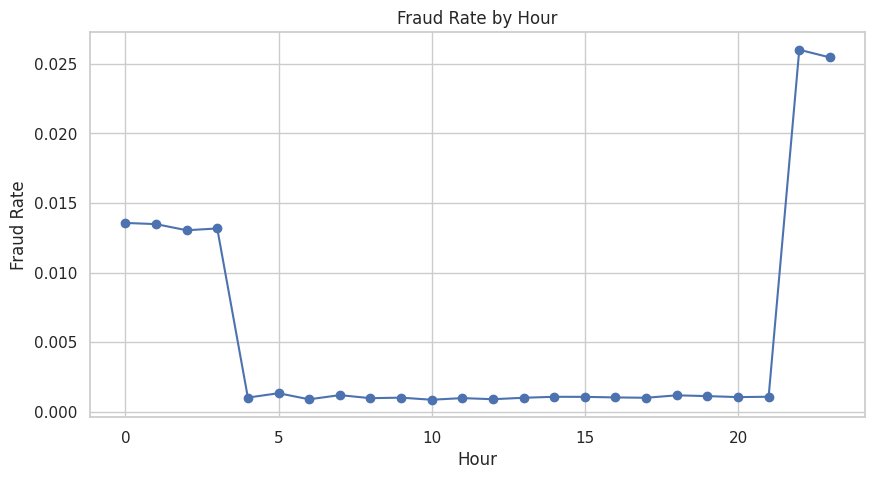

In [ ]:
hourly_fraud = (
    df.groupby('hour')['is_fraud']
      .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    hourly_fraud.index,
    hourly_fraud.values,
    marker='o'
)

plt.title('Fraud Rate by Hour')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')

plt.show()

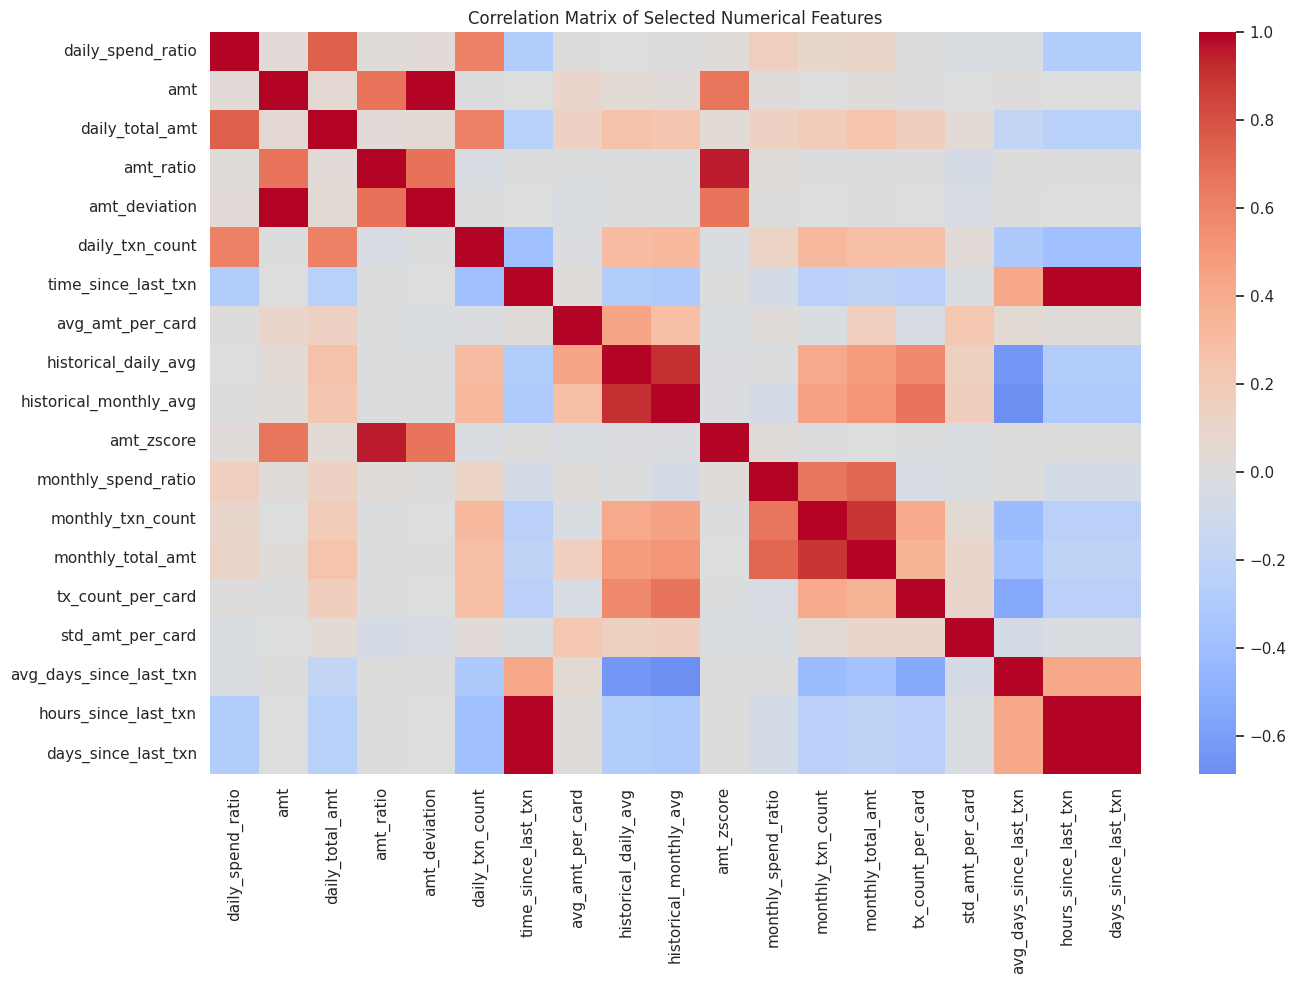

In [ ]:
selected_corr_features = [
    'daily_spend_ratio',
    'amt',
    'daily_total_amt',
    'amt_ratio',
    'amt_deviation',
    'daily_txn_count',
    'time_since_last_txn',
    'avg_amt_per_card',
    'historical_daily_avg',
    'historical_monthly_avg',
    'amt_zscore',
    'monthly_spend_ratio',
    'monthly_txn_count',
    'monthly_total_amt',
    'tx_count_per_card',
    'std_amt_per_card',
    'avg_days_since_last_txn',
    'hours_since_last_txn',
    'days_since_last_txn'
]

corr_matrix = (
    df[selected_corr_features]
    .corr()
)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Matrix of Selected Numerical Features'
)

plt.tight_layout()
plt.show()

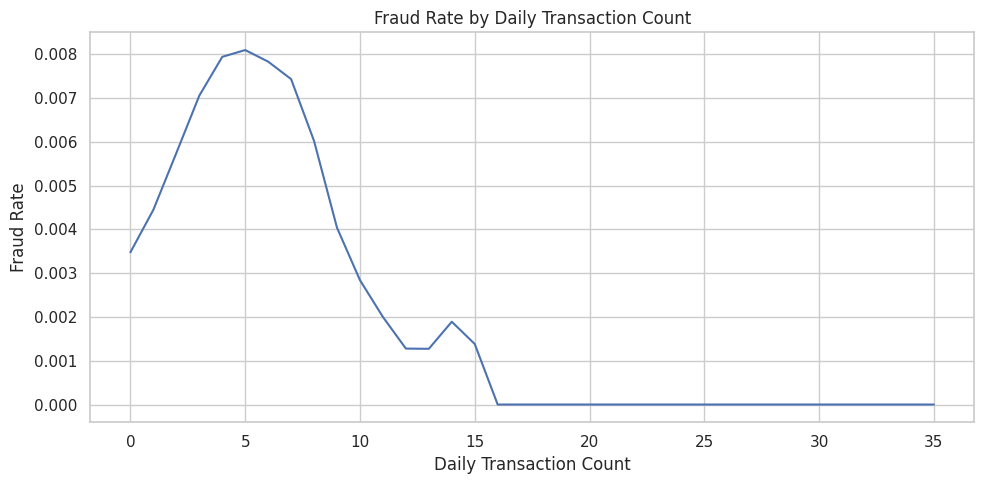

In [ ]:
daily_fraud = (
    df.groupby('daily_txn_count')['is_fraud']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=daily_fraud,
    x='daily_txn_count',
    y='is_fraud'
)

plt.title('Fraud Rate by Daily Transaction Count')
plt.xlabel('Daily Transaction Count')
plt.ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

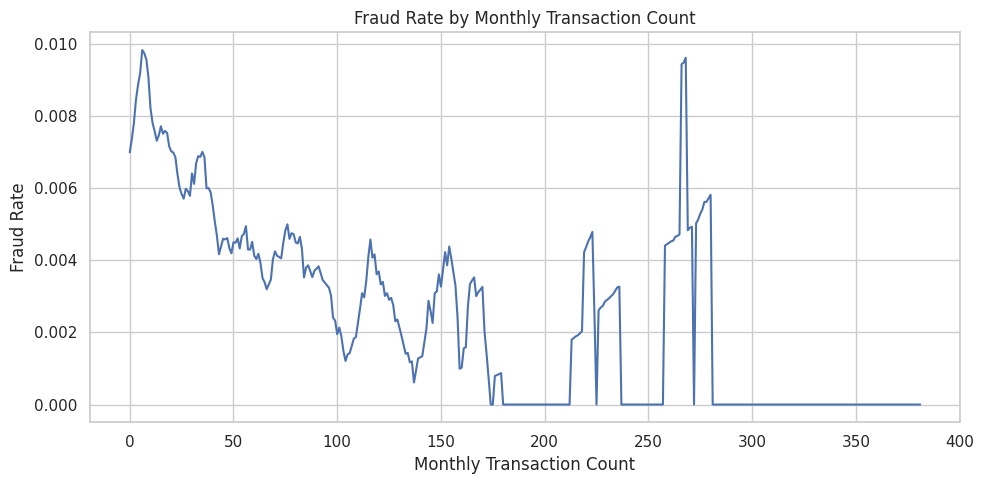

In [ ]:
monthly_fraud = (
    df.groupby('monthly_txn_count')['is_fraud']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_fraud,
    x='monthly_txn_count',
    y='is_fraud'
)

plt.title('Fraud Rate by Monthly Transaction Count')
plt.xlabel('Monthly Transaction Count')
plt.ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

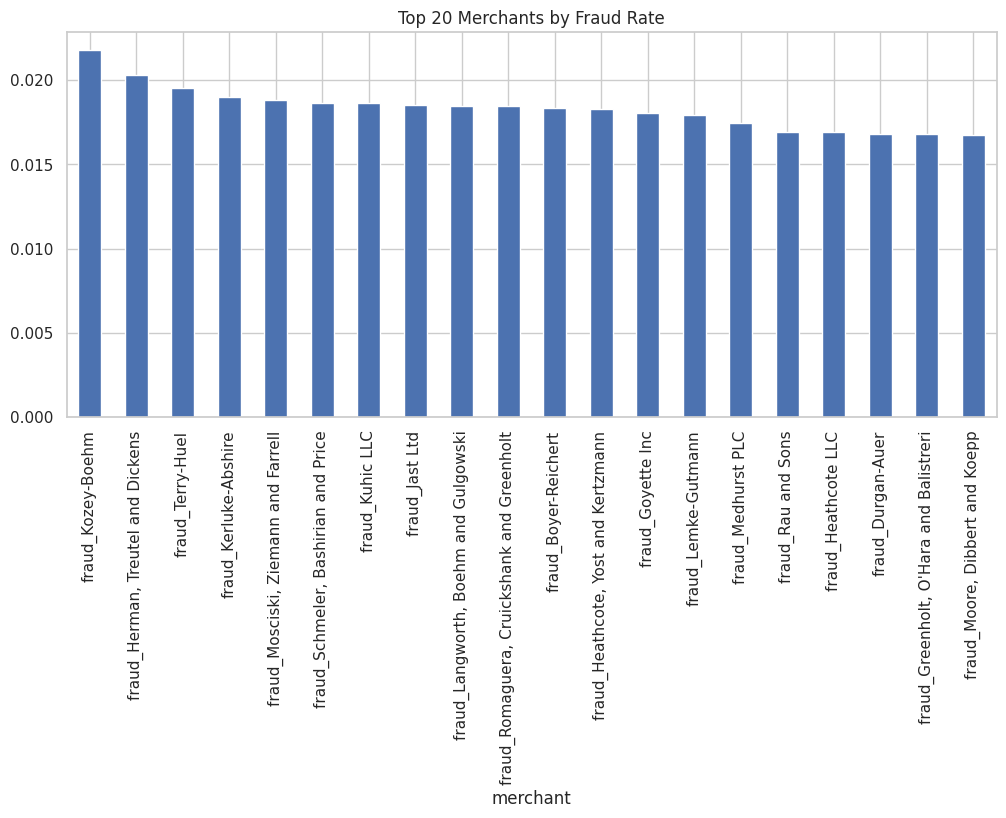

In [ ]:
merchant_fraud = (
    df.groupby('merchant')['is_fraud']
      .mean()
      .sort_values(
          ascending=False
      )
      .head(20)
)

merchant_fraud.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title(
    'Top 20 Merchants by Fraud Rate'
)

plt.show()

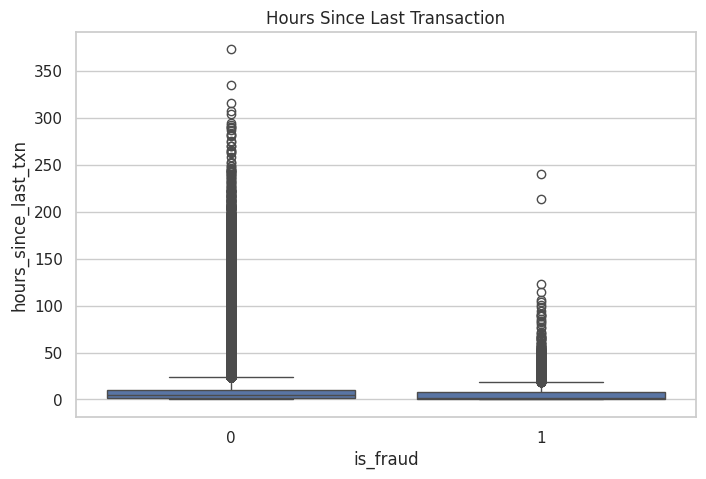

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='hours_since_last_txn',
    data=df
)

plt.title(
    'Hours Since Last Transaction'
)

plt.show()

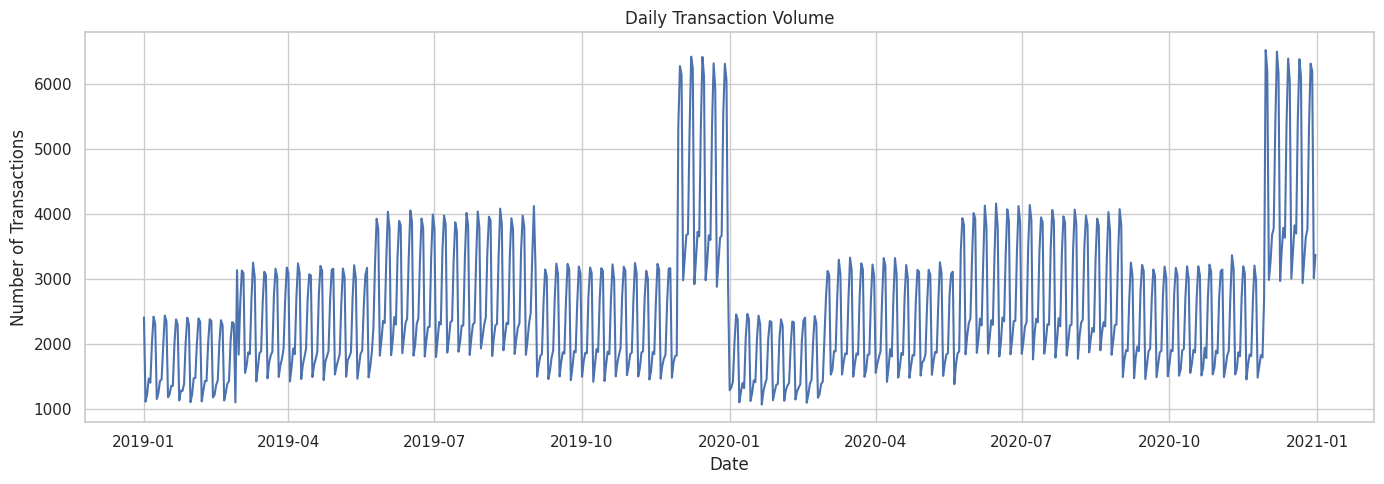

In [ ]:
daily_volume = (
    df.groupby(
        df['trans_date_trans_time'].dt.date
    )
    .size()
)

plt.figure(figsize=(14,5))

plt.plot(
    daily_volume.index,
    daily_volume.values
)

plt.title(
    "Daily Transaction Volume"
)

plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.show()

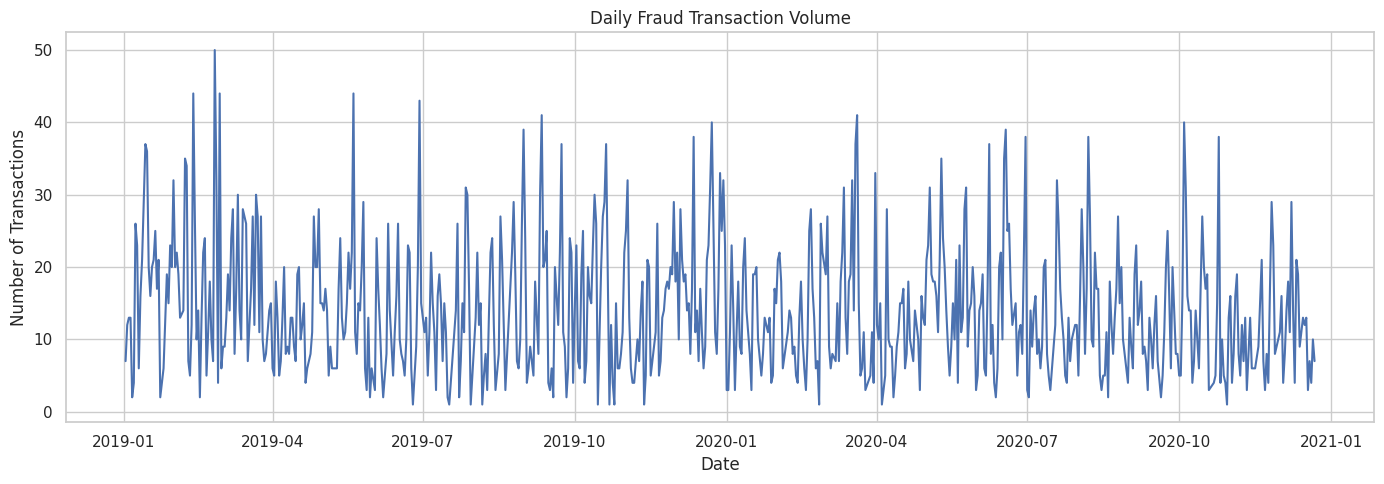

In [ ]:
daily_fraud_volume = (
    df[df['is_fraud'] == 1]
    .groupby(
        df[df['is_fraud'] == 1]['trans_date_trans_time'].dt.date
    )
    .size()
)

plt.figure(figsize=(14,5))

plt.plot(
    daily_fraud_volume.index,
    daily_fraud_volume.values
)

plt.title(
    "Daily Fraud Transaction Volume"
)

plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.show()

/tmp/ipykernel_464/1039701198.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/1039701198.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


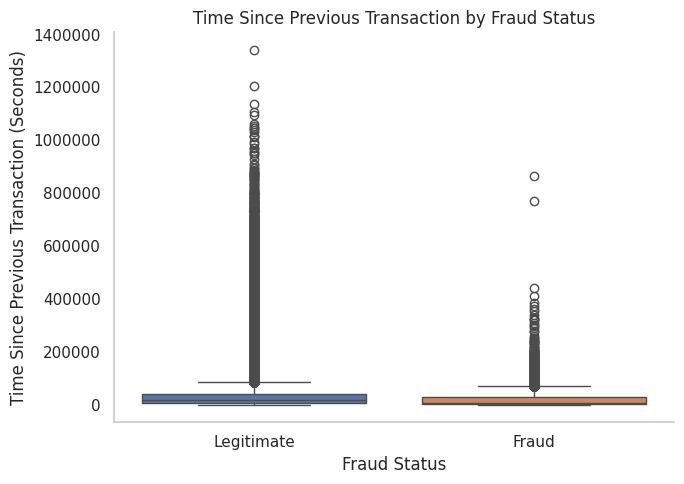

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="time_since_last_txn",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.title(
    "Time Since Previous Transaction by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Time Since Previous Transaction (Seconds)")

# Remove scientific notation (1e6)
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=False)
formatter.set_scientific(False)
formatter.set_useOffset(False)
ax.yaxis.set_major_formatter(formatter)

# Standard formatting
format_boxplot(ax)

plt.show()

/tmp/ipykernel_464/743076609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/743076609.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


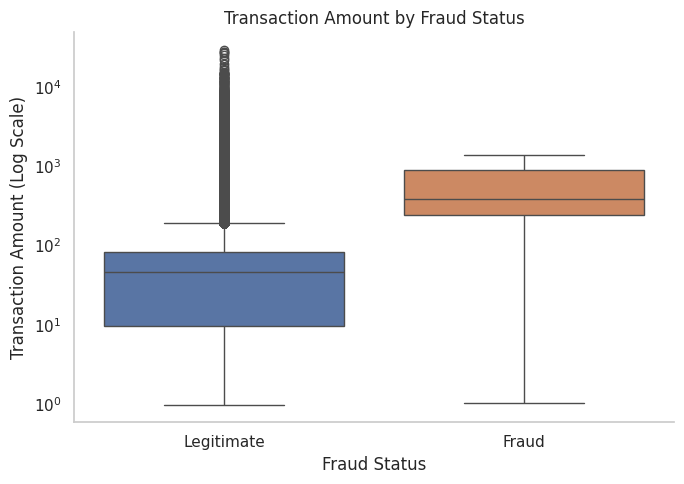

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="amt",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.yscale("log")

plt.title(
    "Transaction Amount by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount (Log Scale)")

format_boxplot(ax)

plt.show()

/tmp/ipykernel_464/3481809410.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/3481809410.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


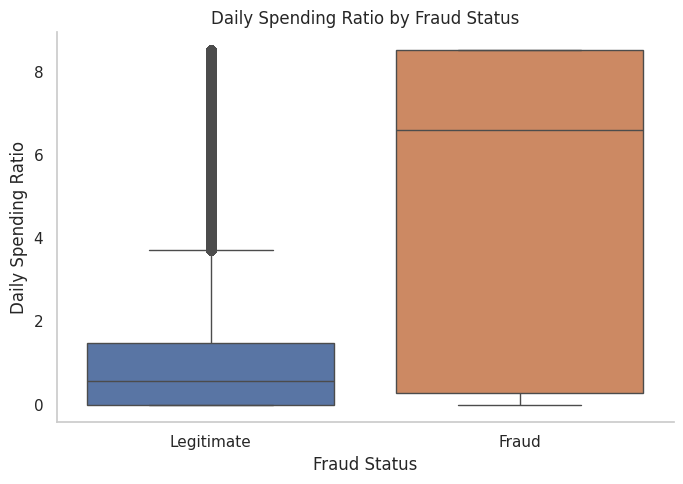

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="daily_spend_ratio",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.title(
    "Daily Spending Ratio by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Daily Spending Ratio")

format_boxplot(ax)

plt.show()

/tmp/ipykernel_464/799852860.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/799852860.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


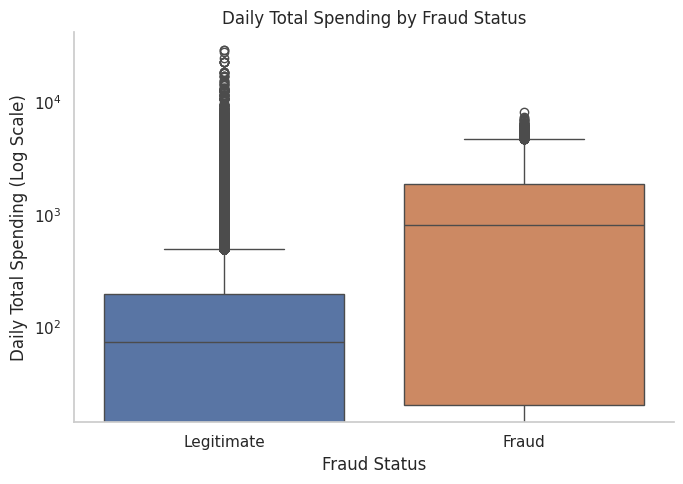

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="daily_total_amt",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.yscale("log")

plt.title(
    "Daily Total Spending by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Daily Total Spending (Log Scale)")

format_boxplot(ax)

plt.show()

/tmp/ipykernel_464/1608179272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/1608179272.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


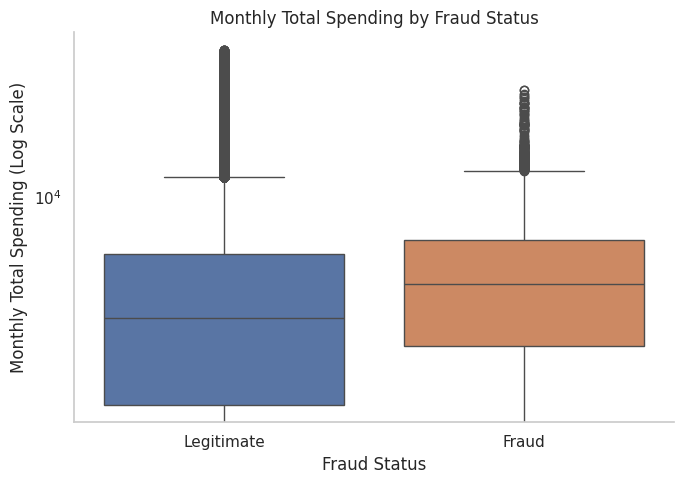

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="monthly_total_amt",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.yscale("log")

plt.title(
    "Monthly Total Spending by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Monthly Total Spending (Log Scale)")

format_boxplot(ax)

plt.show()

/tmp/ipykernel_464/891049154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/891049154.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


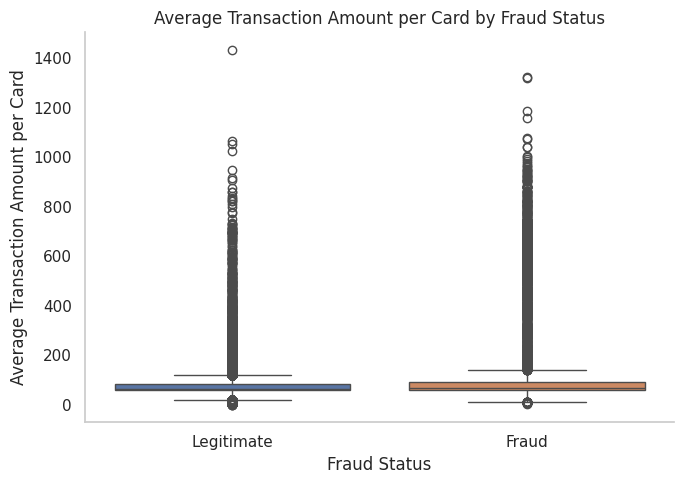

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="avg_amt_per_card",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.title(
    "Average Transaction Amount per Card by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Average Transaction Amount per Card")

format_boxplot(ax)

plt.show()

/tmp/ipykernel_464/2786018956.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/2786018956.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


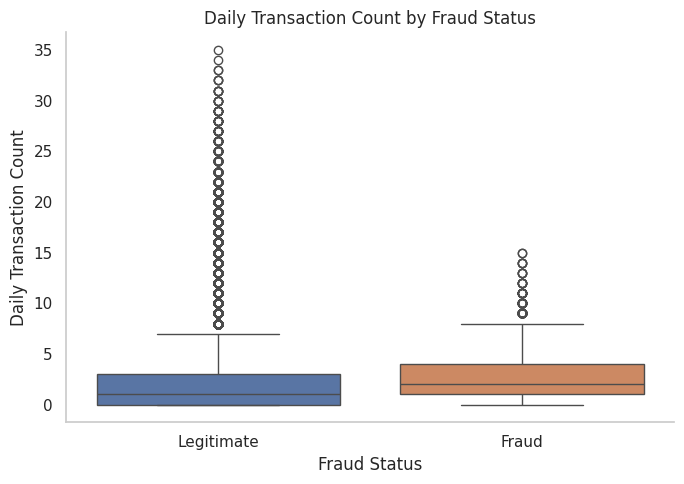

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="daily_txn_count",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.title(
    "Daily Transaction Count by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Daily Transaction Count")

format_boxplot(ax)

plt.show()

In [ ]:
# ==========================================
# REBUILD TEMPORAL FEATURES FROM DUMMIES
# ==========================================

# Reconstruction for grtaph purposes only

temp = df.copy()

# Hour
hour_cols = [f"hour_{i}" for i in range(24)]

temp["hour"] = (
    temp[hour_cols]
    .idxmax(axis=1)
    .str.replace("hour_", "")
    .astype(int)
)

# Day of Week
dow_cols = [f"dow_{i}" for i in range(7)]

temp["day_of_week"] = (
    temp[dow_cols]
    .idxmax(axis=1)
    .str.replace("dow_", "")
    .astype(int)
)

# Month
month_cols = [f"month_{i}" for i in range(1,13)]

temp["month"] = (
    temp[month_cols]
    .idxmax(axis=1)
    .str.replace("month_", "")
    .astype(int)
)

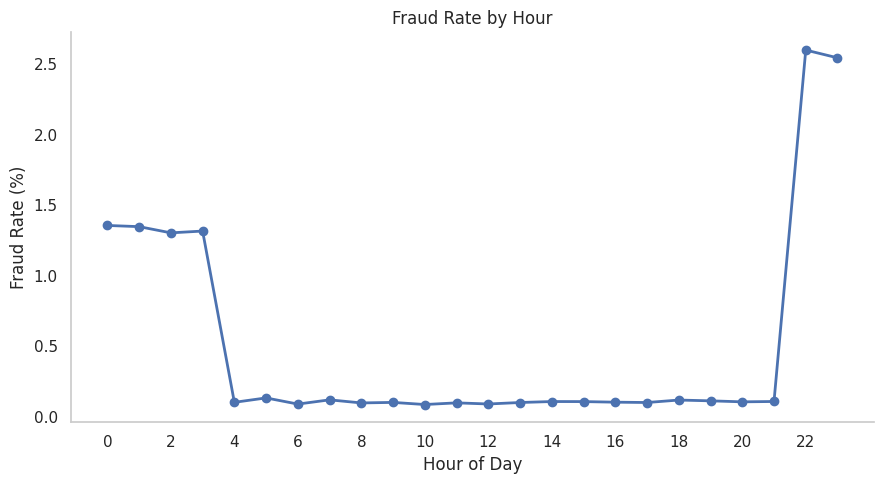

hour
0     1.357
1     1.348
2     1.304
3     1.317
4     0.102
5     0.133
6     0.089
7     0.119
8     0.098
9     0.101
10    0.086
11    0.098
12    0.090
13    0.101
14    0.107
15    0.107
16    0.103
17    0.101
18    0.118
19    0.112
20    0.105
21    0.108
22    2.601
23    2.546
Name: is_fraud, dtype: float64


In [ ]:
# ==========================================
# FRAUD RATE BY HOUR
# ==========================================

hourly_fraud = (
    temp
    .groupby("hour")["is_fraud"]
    .mean()
    * 100
)

plt.figure(figsize=(9,5))

ax = plt.gca()

plt.plot(
    hourly_fraud.index,
    hourly_fraud.values,
    marker="o",
    linewidth=2,
    color="#4C72B0"
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")

plt.xticks(range(0, 24, 2))

format_boxplot(ax)

plt.show()

print(hourly_fraud.round(3))

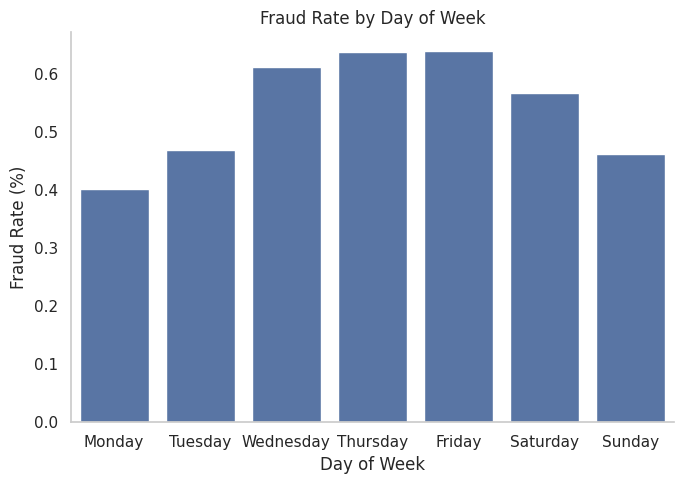

Day
Monday       0.402
Tuesday      0.468
Wednesday    0.612
Thursday     0.637
Friday       0.640
Saturday     0.567
Sunday       0.463
Name: is_fraud, dtype: float64


In [ ]:
# ==========================================
# FRAUD RATE BY DAY OF WEEK
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

temp["Day"] = temp["day_of_week"].map(day_map)

fraud_rate = (
    temp
    .groupby("Day")["is_fraud"]
    .mean()
    .reindex(day_order)
    * 100
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=fraud_rate.index,
    y=fraud_rate.values,
    color="#4C72B0"
)

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")

format_boxplot(ax)

plt.show()

print(fraud_rate.round(3))

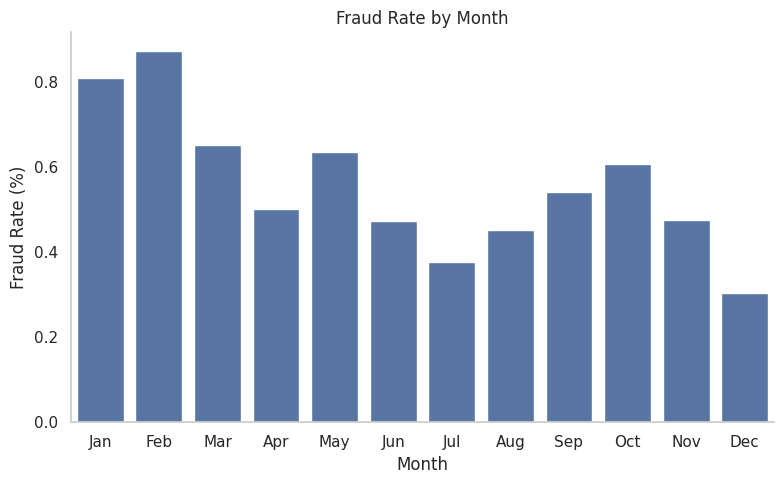

Month
Jan    0.811
Feb    0.873
Mar    0.652
Apr    0.502
May    0.637
Jun    0.472
Jul    0.378
Aug    0.453
Sep    0.541
Oct    0.607
Nov    0.477
Dec    0.303
Name: is_fraud, dtype: float64


In [ ]:
# ==========================================
# FRAUD RATE BY MONTH
# ==========================================

month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

temp["Month"] = temp["month"].map(month_map)

month_order = list(month_map.values())

fraud_rate = (
    temp
    .groupby("Month")["is_fraud"]
    .mean()
    .reindex(month_order)
    * 100
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=fraud_rate.index,
    y=fraud_rate.values,
    color="#4C72B0"
)

plt.title("Fraud Rate by Month")
plt.xlabel("Month")
plt.ylabel("Fraud Rate (%)")

format_boxplot(ax)

plt.show()

print(fraud_rate.round(3))

/tmp/ipykernel_5054/2487564574.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby("Day")["amt"]


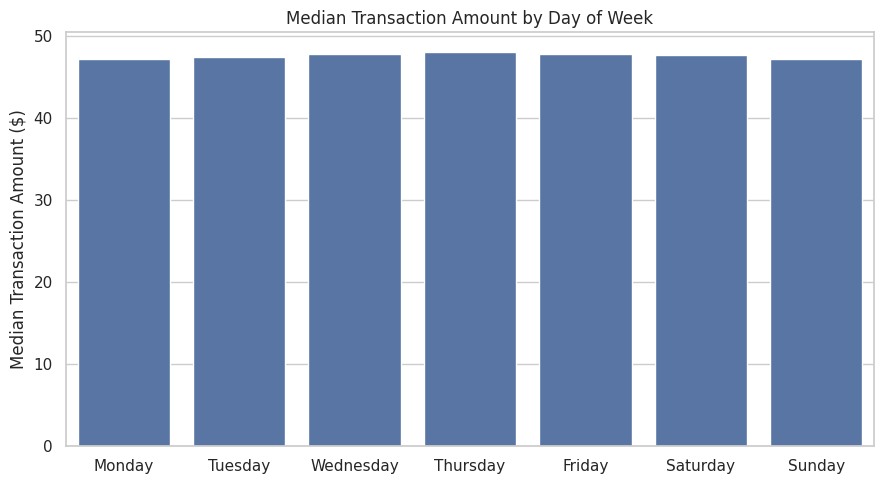

,Day,amt
0,Monday,47.130001
1,Tuesday,47.369999
2,Wednesday,47.720001
3,Thursday,47.990002
4,Friday,47.779999
5,Saturday,47.580002
6,Sunday,47.080002


In [ ]:
# ==========================================
# TRANSACTION AMOUNT BY DAY OF WEEK
# ==========================================

day_map = {
    0:"Monday",
    1:"Tuesday",
    2:"Wednesday",
    3:"Thursday",
    4:"Friday",
    5:"Saturday",
    6:"Sunday"
}

temp["Day"] = pd.Categorical(
    temp["day_of_week"].map(day_map),
    categories=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ],
    ordered=True
)

day_summary = (
    temp.groupby("Day")["amt"]
        .median()
        .reset_index()
)

plt.figure(figsize=(9,5))

sns.barplot(
    data=day_summary,
    x="Day",
    y="amt"
)

plt.title("Median Transaction Amount by Day of Week")

plt.xlabel("")
plt.ylabel("Median Transaction Amount ($)")

plt.tight_layout()

plt.show()

display(day_summary)

/tmp/ipykernel_5054/1703671957.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby("Month")["amt"]


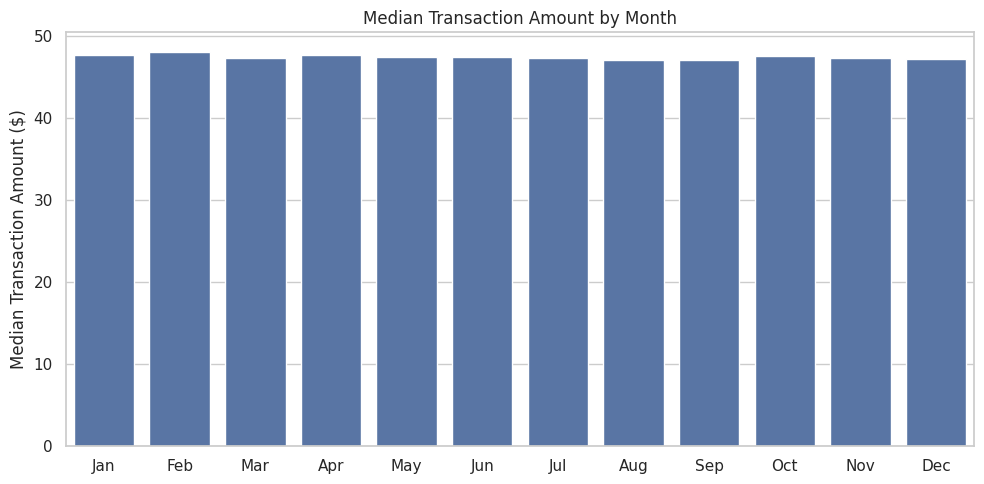

,Month,amt
0,Jan,47.730000
1,Feb,48.099998
2,Mar,47.419998
3,Apr,47.790001
4,May,47.459999
5,Jun,47.500000
6,Jul,47.360001
7,Aug,47.139999
8,Sep,47.150002
9,Oct,47.610001


In [ ]:
# ==========================================
# TRANSACTION AMOUNT BY MONTH
# ==========================================

month_map = {
    1:"Jan",
    2:"Feb",
    3:"Mar",
    4:"Apr",
    5:"May",
    6:"Jun",
    7:"Jul",
    8:"Aug",
    9:"Sep",
    10:"Oct",
    11:"Nov",
    12:"Dec"
}

temp["Month"] = pd.Categorical(
    temp["month"].map(month_map),
    categories=[
        "Jan","Feb","Mar","Apr","May","Jun",
        "Jul","Aug","Sep","Oct","Nov","Dec"
    ],
    ordered=True
)

month_summary = (
    temp.groupby("Month")["amt"]
        .median()
        .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=month_summary,
    x="Month",
    y="amt"
)

plt.title("Median Transaction Amount by Month")

plt.xlabel("")
plt.ylabel("Median Transaction Amount ($)")

plt.tight_layout()

plt.show()

display(month_summary)

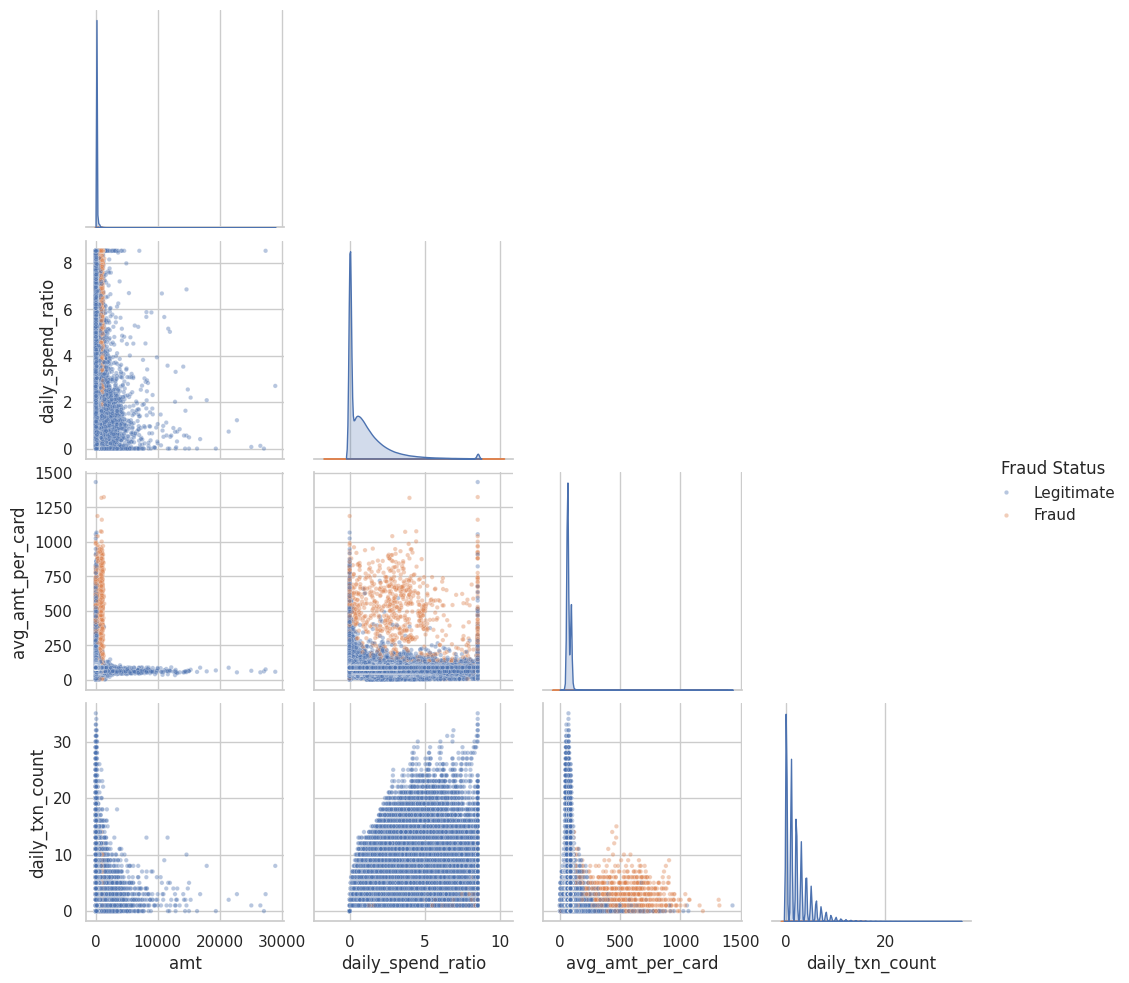

In [ ]:
# ==========================================
# PAIRPLOT OF TOP FEATURES
# ==========================================

pairplot_df = df[
    [
        "amt",
        "daily_spend_ratio",
        "avg_amt_per_card",
        "daily_txn_count",
        "is_fraud"
    ]
].copy()

pairplot_df["Fraud Status"] = pairplot_df["is_fraud"].map({
    0:"Legitimate",
    1:"Fraud"
})

pairplot_df = pairplot_df.drop(columns="is_fraud")

sns.pairplot(
    pairplot_df,
    hue="Fraud Status",
    corner=True,
    plot_kws={"alpha":0.4,"s":10}
)

plt.show()

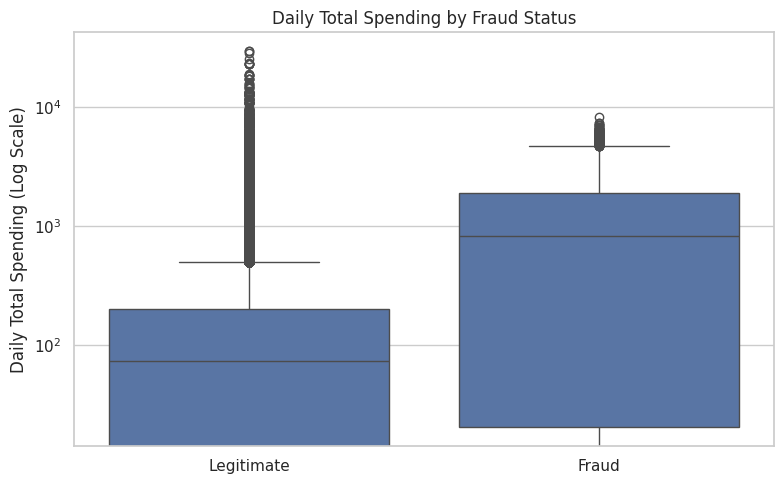

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="daily_total_amt"
)

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.yscale("log")

plt.title(
    "Daily Total Spending by Fraud Status"
)

plt.xlabel("")
plt.ylabel("Daily Total Spending (Log Scale)")

plt.tight_layout()
plt.show()

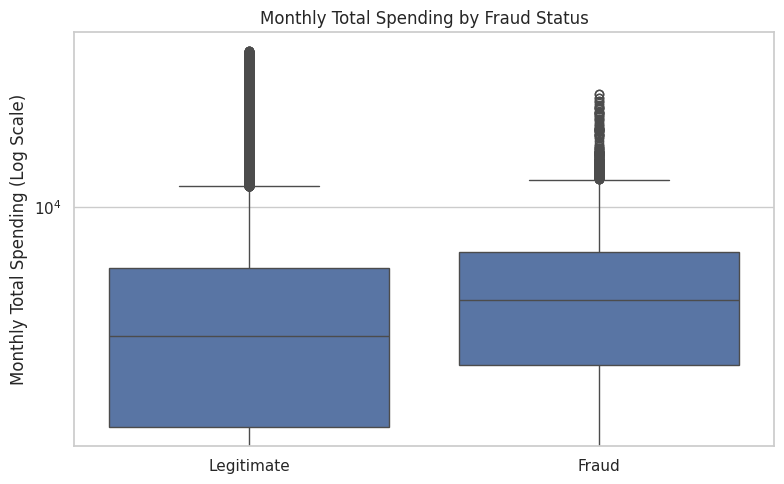

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="monthly_total_amt"
)

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.yscale("log")

plt.title(
    "Monthly Total Spending by Fraud Status"
)

plt.xlabel("")
plt.ylabel("Monthly Total Spending (Log Scale)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_464/3260197420.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/3260197420.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


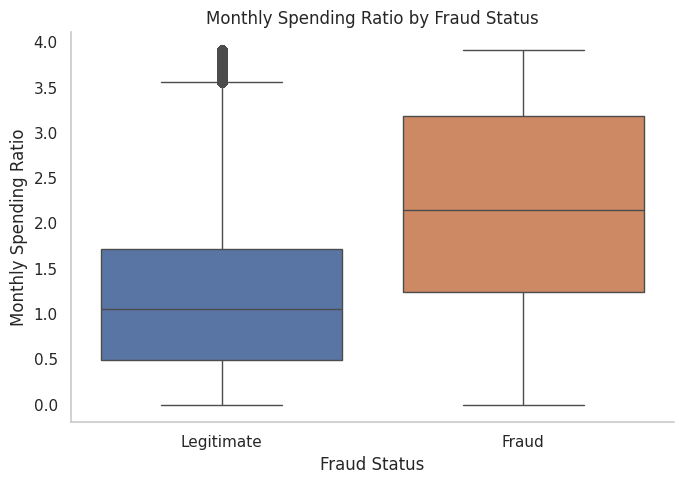

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="monthly_spend_ratio",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.title(
    "Monthly Spending Ratio by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Monthly Spending Ratio")

format_boxplot(ax)

plt.show()

/tmp/ipykernel_464/290851043.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


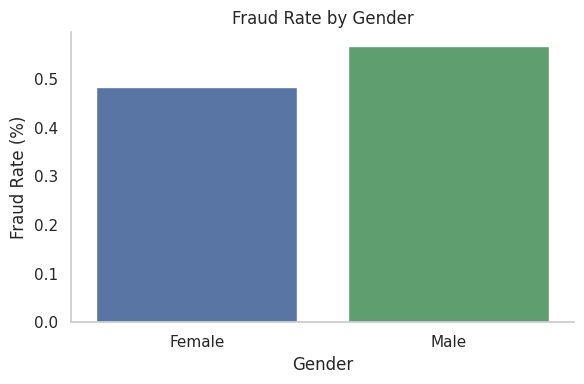

In [ ]:
fraud_gender = (
    df.groupby("gender")["is_fraud"]
      .mean()
      .mul(100)
      .reset_index()
)

# Rename labels
fraud_gender["gender"] = fraud_gender["gender"].replace({
    "F": "Female",
    "M": "Male"
})

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=fraud_gender,
    x="gender",
    y="is_fraud",
    palette=["#4C72B0", "#55A868"]
)

plt.title("Fraud Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate (%)")

# Standard formatting
ax.grid(False)

sns.despine(
    ax=ax,
    top=True,
    right=True,
    left=False,
    bottom=False
)

plt.tight_layout()
plt.show()

**Feature Selection**

Feature Selection Process

1. Numerical features were extracted from the dataset.

2. VarianceThreshold was applied to remove features with near-zero variance.

3. Correlation filtering was performed using the target variable (|r| > 0.01).

4. A temporary XGBoost model was trained using the remaining features.

5. Features were ranked using model-based importance scores.

6. The highest-ranked features were retained for subsequent modeling and interpretation.

In [ ]:
selected_numeric = df.select_dtypes(include=[np.number]).columns.tolist()

remove_cols = [
    'is_fraud'
]

X_full = df[selected_numeric].drop(columns=remove_cols, errors='ignore').fillna(0)

# Variance filtering
selector = VarianceThreshold(0.01)

X_var = selector.fit_transform(X_full)

var_cols = X_full.columns[selector.get_support()]

# Correlation filtering
corr = df[var_cols.tolist() + ['is_fraud']].corr()['is_fraud'].abs()

corr_cols = corr[corr > 0.01].index.tolist()

corr_cols.remove('is_fraud')

# TEMP MODEL
temp_model = xgb.XGBClassifier(
    n_estimators=100,
    eval_metric='logloss'
)

temp_model.fit(
    X_full[corr_cols],
    df['is_fraud']
)

importance = pd.Series(
    temp_model.feature_importances_,
    index=corr_cols
)

top_features = (
    importance
    .sort_values(ascending=False)
    .head(50)
    .index
    .tolist()
)

print("X_full:")
print(X_full.columns.tolist())

print("Top Features:")
print(top_features)

X_full:
['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_weekend', 'is_night', 'time_since_last_txn', 'avg_amt_per_card', 'std_amt_per_card', 'amt_deviation', 'amt_ratio', 'amt_zscore', 'tx_count_per_card', 'unique_merchants_per_card', 'historical_merchant_freq', 'distance_from_home', 'days_since_last_txn', 'hours_since_last_txn', 'avg_time_since_last_txn', 'avg_days_since_last_txn', 'daily_txn_count', 'daily_count_unique_categories_per_card', 'daily_count_unique_merchants_per_card', 'monthly_txn_count', 'daily_total_amt', 'historical_daily_avg', 'daily_spend_ratio', 'monthly_total_amt', 'historical_monthly_avg', 'monthly_spend_ratio', 'hour_0', 'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_

In [ ]:
print("\nFEATURE SELECTION SUMMARY")

print(
    "Initial Numerical Features:",
    len(selected_numeric)
)

print("\nINITIAL FEATURES:")
print(selected_numeric)

print(
    "\nAfter Variance Threshold:",
    len(var_cols)
)

print("\nFEATURES RETAINED AFTER VARIANCE THRESHOLD:")
print(var_cols)

# Features removed by variance threshold
removed_variance = list(
    set(selected_numeric) - set(var_cols)
)

print("\nFEATURES REMOVED BY VARIANCE THRESHOLD:")
print(sorted(removed_variance))

print(
    "\nAfter Correlation Filter:",
    len(corr_cols)
)

print("\nFEATURES RETAINED AFTER CORRELATION FILTER:")
print(corr_cols)

# Features removed by correlation filtering
removed_correlation = list(
    set(var_cols) - set(corr_cols)
)

print("\nFEATURES REMOVED BY CORRELATION FILTER:")
print(sorted(removed_correlation))

print(
    "\nFinal Selected Features:",
    len(top_features)
)

print("\nFINAL SELECTED FEATURES:")
print(top_features)

# Features removed during feature importance selection
removed_importance = list(
    set(corr_cols) - set(top_features)
)

print("\nFEATURES REMOVED DURING FEATURE IMPORTANCE SELECTION:")
print(sorted(removed_importance))


FEATURE SELECTION SUMMARY
Initial Numerical Features: 80

INITIAL FEATURES:
['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'is_weekend', 'is_night', 'time_since_last_txn', 'avg_amt_per_card', 'std_amt_per_card', 'amt_deviation', 'amt_ratio', 'amt_zscore', 'tx_count_per_card', 'unique_merchants_per_card', 'historical_merchant_freq', 'distance_from_home', 'days_since_last_txn', 'hours_since_last_txn', 'avg_time_since_last_txn', 'avg_days_since_last_txn', 'daily_txn_count', 'daily_count_unique_categories_per_card', 'daily_count_unique_merchants_per_card', 'monthly_txn_count', 'daily_total_amt', 'historical_daily_avg', 'daily_spend_ratio', 'monthly_total_amt', 'historical_monthly_avg', 'monthly_spend_ratio', 'hour_0', 'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hou

**Top Features**

In [ ]:
# FEATURE IMPORTANCE

importance_df = pd.DataFrame({
    'Feature': top_features,
    'Importance': temp_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

importance_df.head(20)

,Feature,Importance
18,hour_2,0.325203
2,daily_txn_count,0.271068
15,month_12,0.076232
16,hour_1,0.064693
20,hour_23,0.060757
0,daily_total_amt,0.037377
6,amt_deviation,0.036332
9,historical_monthly_avg,0.032155
4,daily_spend_ratio,0.024659
22,monthly_total_amt,0.020839


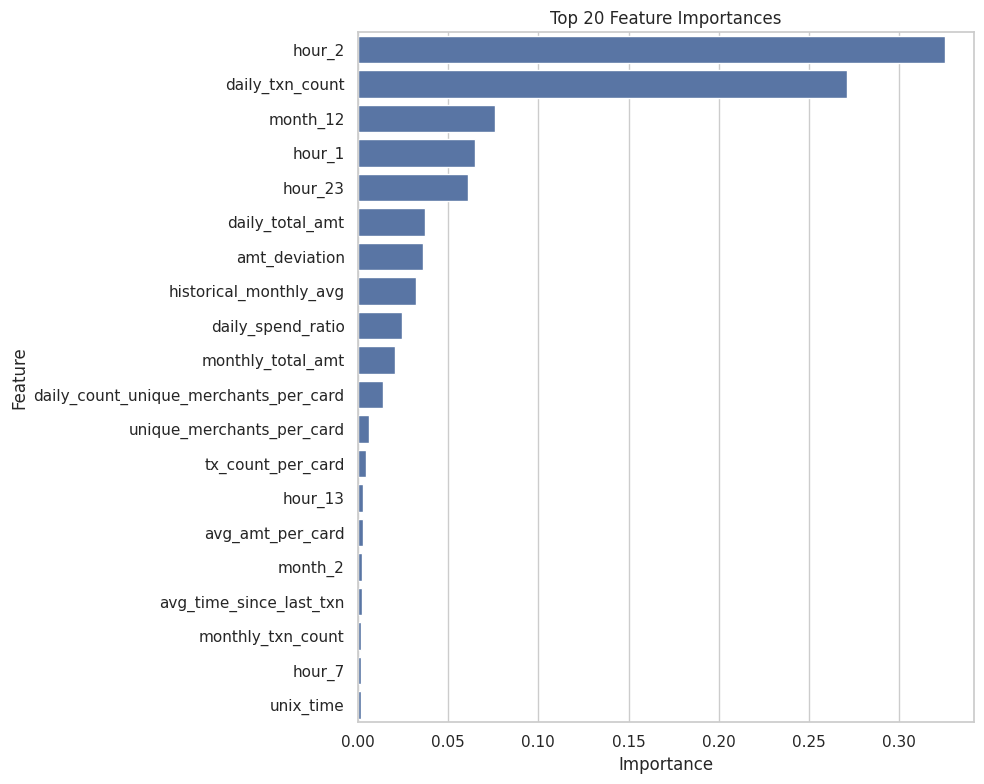

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df.head(20),
    y='Feature',
    x='Importance'
)

plt.title(
    'Top 20 Feature Importances'
)

plt.tight_layout()

plt.show()

**Additional EDA and Feature Analysis**

/tmp/ipykernel_464/2417396448.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/2417396448.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


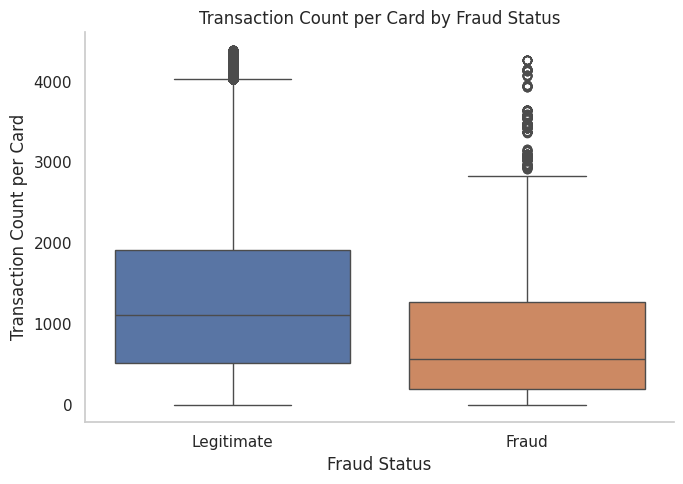

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="tx_count_per_card",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.title(
    "Transaction Count per Card by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Transaction Count per Card")

format_boxplot(ax)

plt.show()

In [ ]:
# Average daily transaction count per card

df["avg_daily_txn_count"] = (
    df.groupby("cc_num")["daily_txn_count"]
      .transform("mean")
)

# Average monthly transaction count per card

df["avg_monthly_txn_count"] = (
    df.groupby("cc_num")["monthly_txn_count"]
      .transform("mean")
)

/tmp/ipykernel_464/1976474842.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/1976474842.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


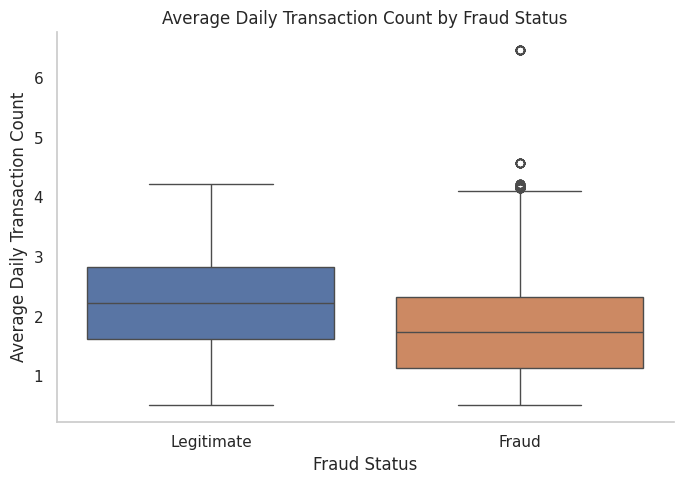

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="avg_daily_txn_count",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.title(
    "Average Daily Transaction Count by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Average Daily Transaction Count")

format_boxplot(ax)

plt.show()

/tmp/ipykernel_464/2990310226.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_464/2990310226.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


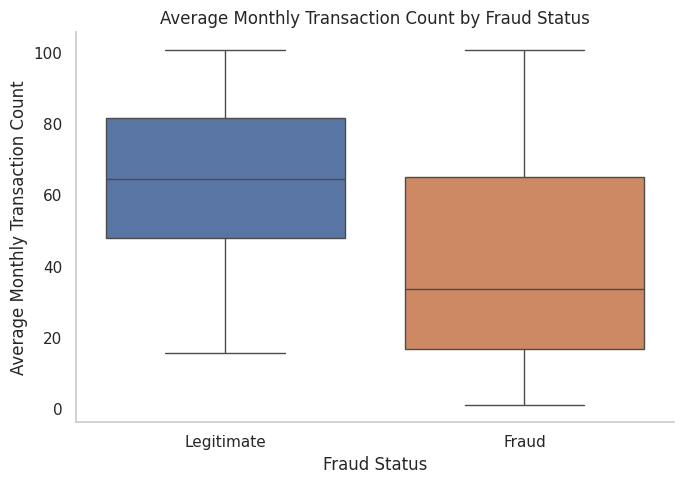

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=df,
    x="is_fraud",
    y="avg_monthly_txn_count",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xticklabels([
    "Legitimate",
    "Fraud"
])

plt.title(
    "Average Monthly Transaction Count by Fraud Status"
)

plt.xlabel("Fraud Status")
plt.ylabel("Average Monthly Transaction Count")

format_boxplot(ax)

plt.show()

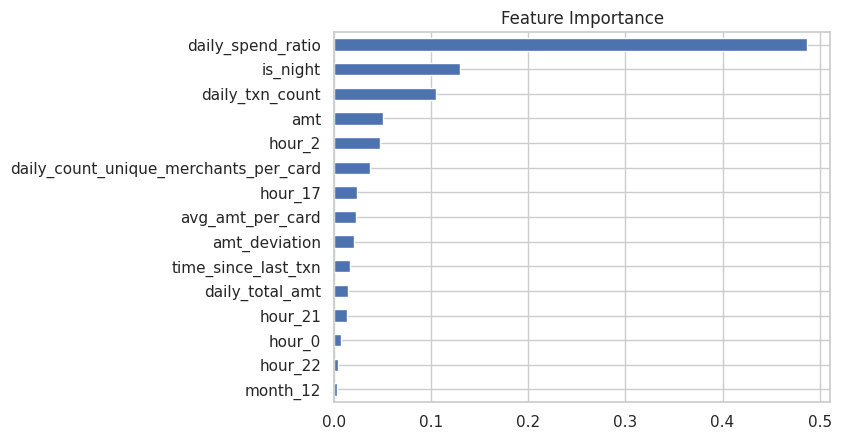

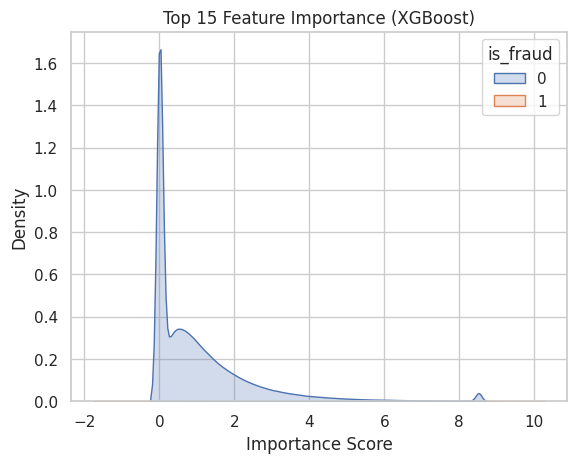

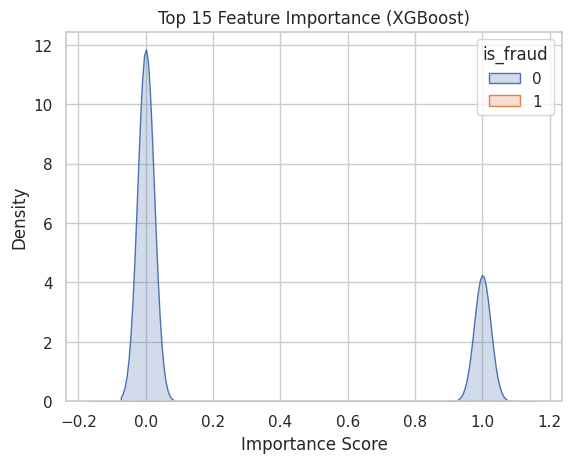

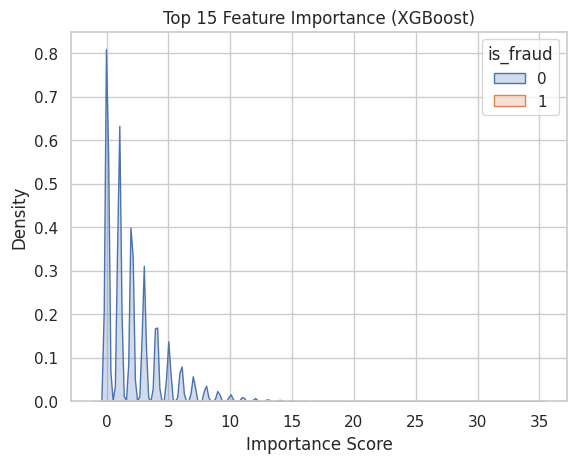

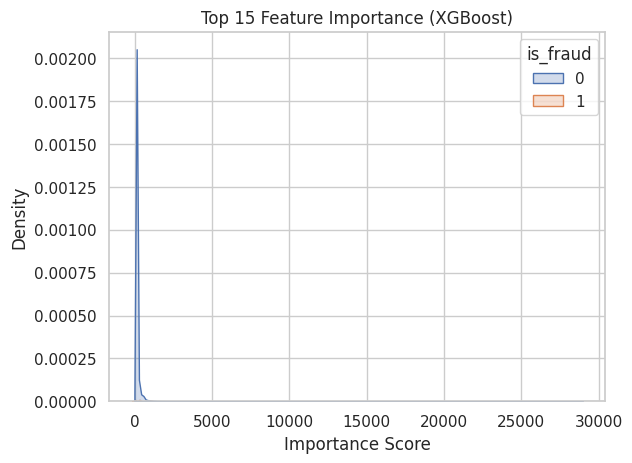

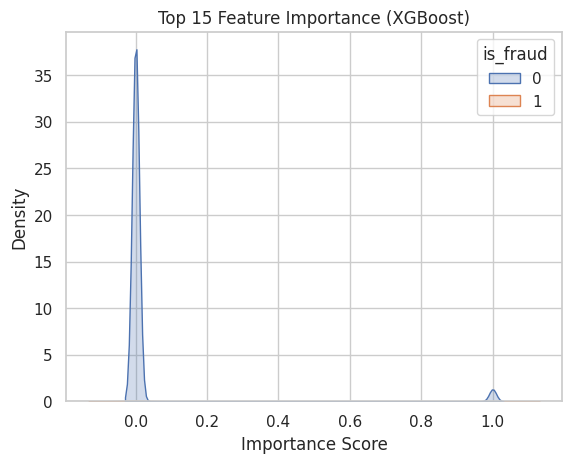

In [ ]:
importance.sort_values().tail(15).plot(kind='barh')
plt.title("Feature Importance")
plt.show()

for col in top_features[:5]:
    sns.kdeplot(data=df, x=col, hue='is_fraud', fill=True)
    plt.title("Top 15 Feature Importance (XGBoost)")
    plt.xlabel("Importance Score")
    plt.show()

**Data Preparation**

In [ ]:
df = df.sort_values(
    'trans_date_trans_time'
)

train_size = int(len(df) * 0.70)

test_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size]

test_df = df.iloc[
    train_size:
    train_size + test_size
]

oot_df = df.iloc[
    train_size + test_size:
]

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print("OOT Shape:", oot_df.shape)

print("\nDate Ranges")

print(
    "Train:",
    train_df['trans_date_trans_time'].min(),
    "to",
    train_df['trans_date_trans_time'].max()
)

print(
    "Test:",
    test_df['trans_date_trans_time'].min(),
    "to",
    test_df['trans_date_trans_time'].max()
)

print(
    "OOT:",
    oot_df['trans_date_trans_time'].min(),
    "to",
    oot_df['trans_date_trans_time'].max()
)

print("\nFraud Rates")

print(
    "Train:",
    train_df['is_fraud'].mean()
)

print(
    "Test:",
    test_df['is_fraud'].mean()
)

print(
    "OOT:",
    oot_df['is_fraud'].mean()
)

Train Shape: (1296675, 107)
Test Shape: (277859, 107)
OOT Shape: (277860, 107)

Date Ranges
Train: 2019-01-01 00:00:18 to 2020-06-21 12:13:37
Test: 2020-06-21 12:14:25 to 2020-10-03 00:58:23
OOT: 2020-10-03 00:59:48 to 2020-12-31 23:59:34

Fraud Rates
Train: 0.005788651743883394
Test: 0.0043943151022640976
OOT: 0.00332541567695962


In [ ]:
# ==========================================
# RAW FEATURE DATASETS
# ==========================================

raw_features = [
    'cc_num',
    'amt',
    'zip',
    'lat',
    'long',
    'city_pop',
    'unix_time',
    'merch_lat',
    'merch_long'
]

X_train_raw = train_df[raw_features].copy()
y_train_raw = train_df['is_fraud'].copy()

X_test_raw = test_df[raw_features].copy()
y_test_raw = test_df['is_fraud'].copy()

X_oot_raw = oot_df[raw_features].copy()
y_oot_raw = oot_df['is_fraud'].copy()

from sklearn.preprocessing import StandardScaler

raw_scaler = StandardScaler()

X_train_raw_scaled = raw_scaler.fit_transform(
    X_train_raw
)

X_test_raw_scaled = raw_scaler.transform(
    X_test_raw
)

X_oot_raw_scaled = raw_scaler.transform(
    X_oot_raw
)

print("Raw Train Shape:", X_train_raw.shape)
print("Raw Test Shape:", X_test_raw.shape)
print("Raw OOT Shape:", X_oot_raw.shape)

Raw Train Shape: (1296675, 9)
Raw Test Shape: (277859, 9)
Raw OOT Shape: (277860, 9)


In [ ]:
selected_features_pre_filter = corr_cols.copy()

In [ ]:
X_train = train_df[selected_features_pre_filter]
X_test = test_df[selected_features_pre_filter]
X_oot = oot_df[selected_features_pre_filter]

**RESUME HERE**

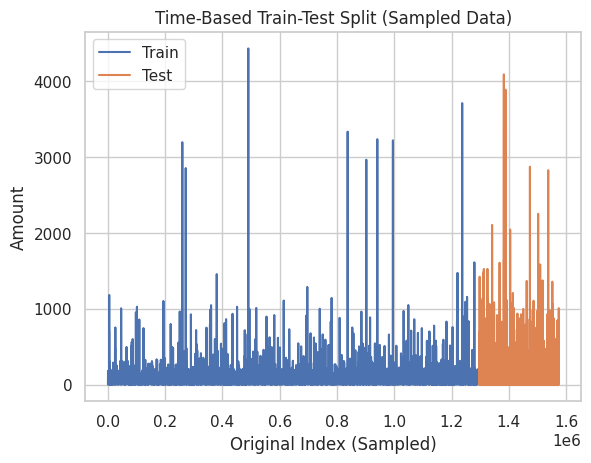

In [ ]:
plt.figure()

# Sample data for plotting to avoid OverflowError with large datasets
sample_size = 10000

# Sample from train_df while maintaining chronological order
if len(train_df) > sample_size:
    train_df_sampled = train_df.sample(n=sample_size, random_state=42).sort_index()
else:
    train_df_sampled = train_df

# Sample from test_df while maintaining chronological order
if len(test_df) > sample_size:
    test_df_sampled = test_df.sample(n=sample_size, random_state=42).sort_index()
else:
    test_df_sampled = test_df

plt.plot(train_df_sampled['amt'], label='Train')
plt.plot(test_df_sampled['amt'], label='Test')
plt.legend()
plt.title('Time-Based Train-Test Split (Sampled Data)')
plt.xlabel('Original Index (Sampled)')
plt.ylabel('Amount')
plt.show()

In [ ]:
# Define X and y for train, test, and oot datasets
X_train = train_df[selected_features_pre_filter].copy()
y_train = train_df['is_fraud'].copy()

X_test = test_df[selected_features_pre_filter].copy()
y_test = test_df['is_fraud'].copy()

X_oot = oot_df[selected_features_pre_filter].copy()
y_oot = oot_df['is_fraud'].copy()

In [ ]:
# TEMP XGBOOST (FOR FEATURE SELECTION)

from xgboost import XGBClassifier

temp_xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

temp_xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# SELECT TOP FEATURES

importance_series = pd.Series(
    temp_xgb.feature_importances_,
    index=X_train.columns  # IMPORTANT: use original columns
)

top_features = importance_series.sort_values(ascending=False).head(50).index.tolist()

print("Selected features:", top_features)

Selected features: ['is_night', 'historical_monthly_avg', 'daily_total_amt', 'unique_merchants_per_card', 'daily_spend_ratio', 'amt', 'hour_22', 'daily_txn_count', 'daily_count_unique_merchants_per_card', 'time_since_last_txn', 'hour_23', 'hour_0', 'amt_ratio', 'monthly_spend_ratio', 'hour_3', 'hour_2', 'amt_deviation', 'hour_1', 'historical_daily_avg', 'avg_amt_per_card', 'avg_days_since_last_txn', 'month_12', 'hour_4', 'unix_time', 'amt_zscore', 'avg_time_since_last_txn', 'monthly_total_amt', 'monthly_txn_count', 'tx_count_per_card', 'hour_8', 'hour_9', 'std_amt_per_card', 'month_2', 'hour_7', 'hour_18', 'hour_6', 'hour_20', 'hour_21', 'hour_16', 'hour_19', 'hour_14', 'hour_17', 'hours_since_last_txn', 'days_since_last_txn', 'hour_15', 'hour_10', 'hour_11', 'hour_12', 'hour_13']


In [ ]:
# REBUILD DATASET WITH TOP FEATURES

X_train = X_train[top_features].fillna(0)

X_test = X_test[top_features].fillna(0)

X_oot = X_oot[top_features].fillna(0)

**New Graphs as per Panel**

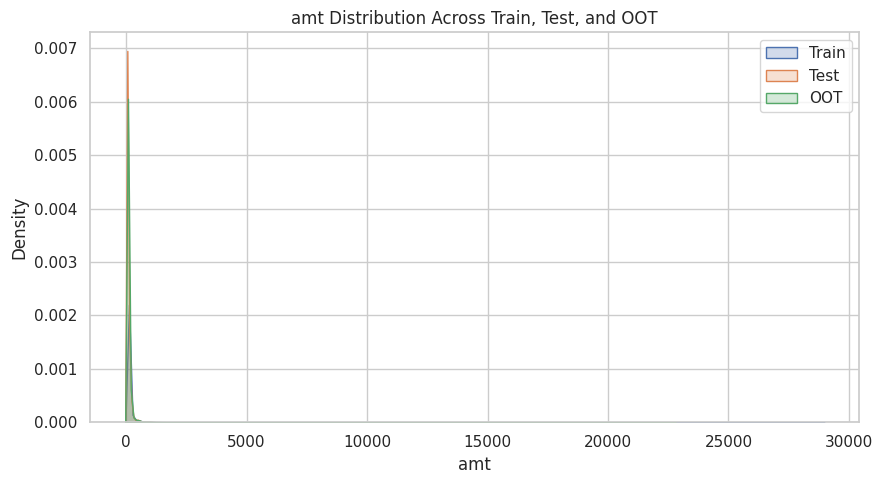


AMT
              mean         std  min     median           max
Dataset                                                     
OOT      69.272408  163.657761  1.0  47.330002  22768.109375
Test     69.513214  149.515106  1.0  47.270000  16837.080078
Train    70.351036  160.316040  1.0  47.520000  28948.900391


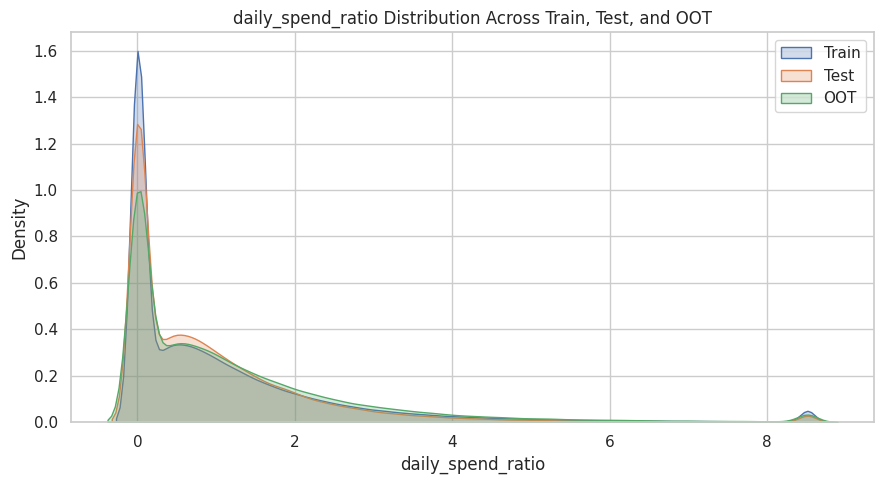


DAILY_SPEND_RATIO
             mean       std  min    median       max
Dataset                                             
OOT      1.208193  1.552178  0.0  0.725721  8.517709
Test     0.966492  1.333025  0.0  0.560150  8.517709
Train    1.058058  1.510033  0.0  0.549612  8.517709


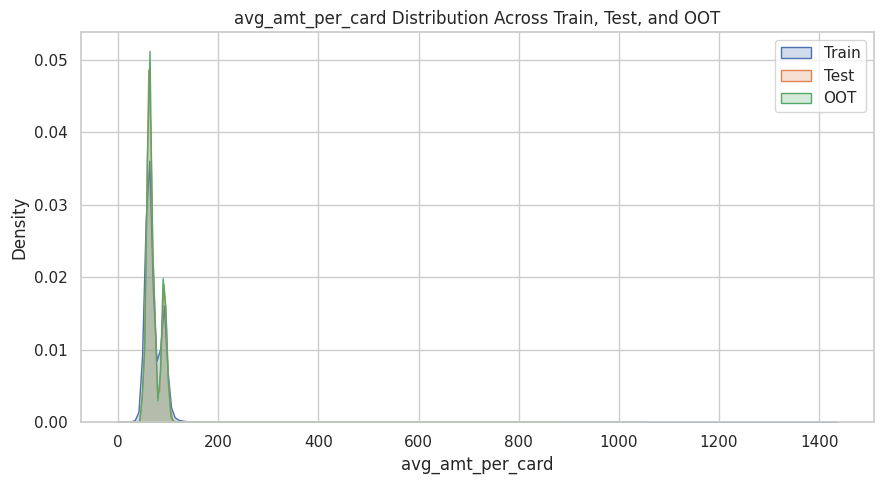


AVG_AMT_PER_CARD
              mean        std   min     median          max
Dataset                                                    
OOT      70.007866  16.074101  9.16  64.554486  1041.540039
Test     70.098604  17.008218  7.84  64.763385   864.501003
Train    70.427083  21.576682  1.03  65.046288  1433.540039


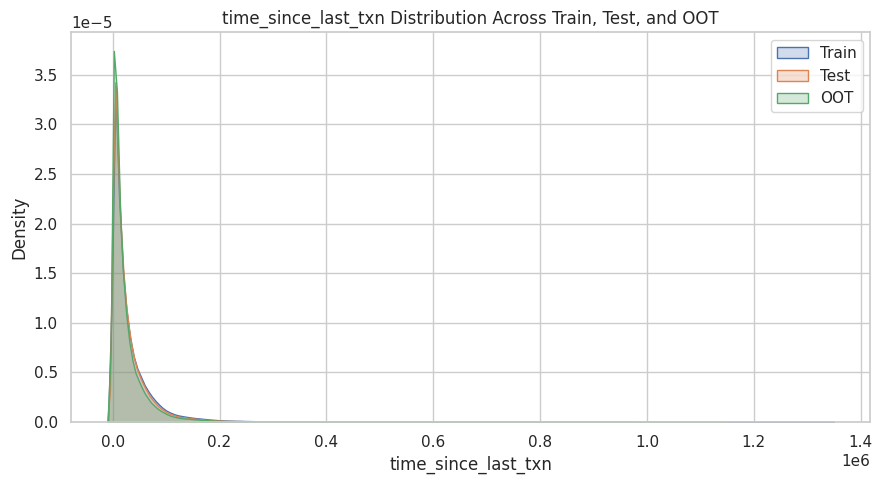


TIME_SINCE_LAST_TXN
                 mean           std  min   median        max
Dataset                                                     
OOT      25489.324329  38805.506100  0.0  12474.0  1136944.0
Test     29180.847545  40787.635861  0.0  15418.0   971874.0
Train    32460.388633  47391.441671  0.0  16536.0  1341471.0


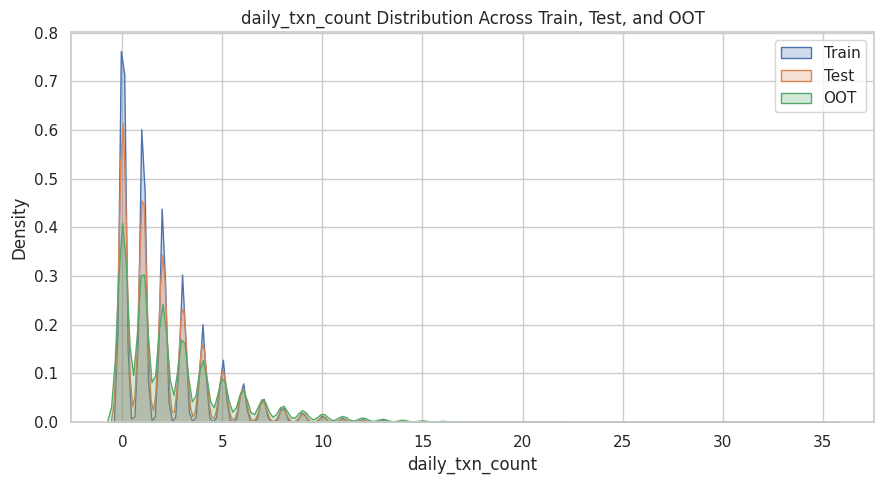


DAILY_TXN_COUNT
             mean       std  min  median  max
Dataset                                      
OOT      2.687141  3.044144    0     2.0   35
Test     2.098230  2.300502    0     1.0   22
Train    1.999057  2.324247    0     1.0   33


In [ ]:
# ==========================================
# FEATURE DISTRIBUTION ACROSS DATASETS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_features = [
    "amt",
    "daily_spend_ratio",
    "avg_amt_per_card",
    "time_since_last_txn",
    "daily_txn_count"
]

for feature in plot_features:

    plt.figure(figsize=(9,5))

    sns.kdeplot(
        X_train[feature],
        label="Train",
        fill=True,
        common_norm=False,
        alpha=0.25
    )

    sns.kdeplot(
        X_test[feature],
        label="Test",
        fill=True,
        common_norm=False,
        alpha=0.25
    )

    sns.kdeplot(
        X_oot[feature],
        label="OOT",
        fill=True,
        common_norm=False,
        alpha=0.25
    )

    plt.title(f"{feature} Distribution Across Train, Test, and OOT")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()

    plt.tight_layout()
    plt.show()

    summary = pd.concat([
        pd.DataFrame({"Dataset":"Train","Value":X_train[feature]}),
        pd.DataFrame({"Dataset":"Test","Value":X_test[feature]}),
        pd.DataFrame({"Dataset":"OOT","Value":X_oot[feature]})
    ])

    print("\n" + "="*70)
    print(feature.upper())
    print("="*70)

    print(
        summary.groupby("Dataset")["Value"]
        .agg(["mean","std","min","median","max"])
    )

In [ ]:
# RE-SAMPLING + SCALING
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler

# Fill any potential NaN values in the feature sets with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)
X_oot = X_oot.fillna(0)

# BASELINE DATA
X_train_base = X_train.copy()
y_train_base = y_train.copy()

scaler_base = StandardScaler()

X_train_base_scaled = scaler_base.fit_transform(
    X_train_base
)

X_test_base_scaled = scaler_base.transform(
    X_test
)

X_oot_base_scaled = scaler_base.transform(
    X_oot
)

# UNDERSAMPLED DATA
rus = RandomUnderSampler(
    sampling_strategy=0.1,
    random_state=42
)

X_train_res, y_train_res = rus.fit_resample(
    X_train,
    y_train
)

# # # # #

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_res
)

X_test_scaled = scaler.transform(
    X_test
)

X_oot_scaled = scaler.transform(
    X_oot
)

print("Original Train Shape:", X_train.shape)
print("Resampled Shape:", X_train_res.shape)

print("\nOriginal Fraud Rate:")
print(y_train.value_counts(normalize=True))

print("\nAfter Resample:")
print(y_train_res.value_counts(normalize=True))

Original Train Shape: (1296675, 49)
Resampled Shape: (82566, 49)

Original Fraud Rate:
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

After Resample:
is_fraud
0    0.909091
1    0.090909
Name: proportion, dtype: float64


**New Graph as per Panel**

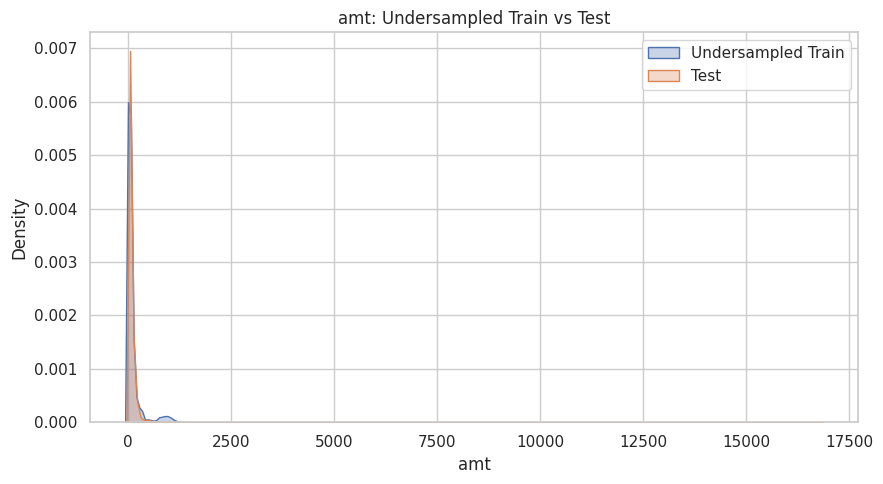


AMT
                          mean         std  min     median           max
Dataset                                                                 
Test                 69.513214  149.515106  1.0  47.270000  16837.080078
Undersampled Train  109.313057  227.199112  1.0  50.869999  13536.839844


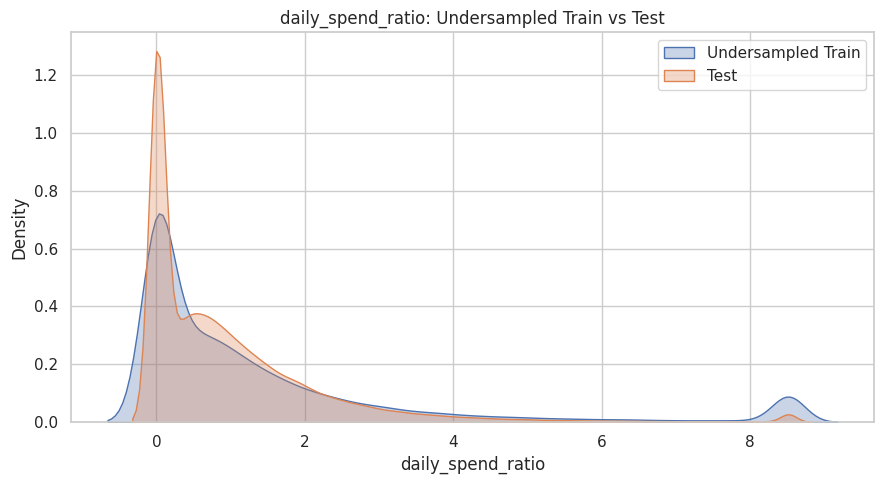


DAILY_SPEND_RATIO
                        mean       std  min    median       max
Dataset                                                        
Test                0.966492  1.333025  0.0  0.560150  8.517709
Undersampled Train  1.408200  2.118550  0.0  0.628662  8.517709


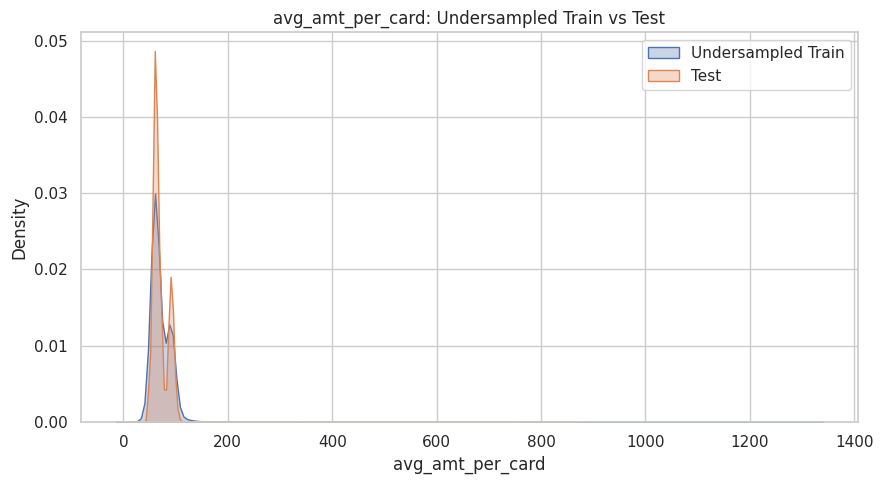


AVG_AMT_PER_CARD
                         mean        std   min     median          max
Dataset                                                               
Test                70.098604  17.008218  7.84  64.763385   864.501003
Undersampled Train  74.485387  48.809391  1.13  65.438184  1324.800049


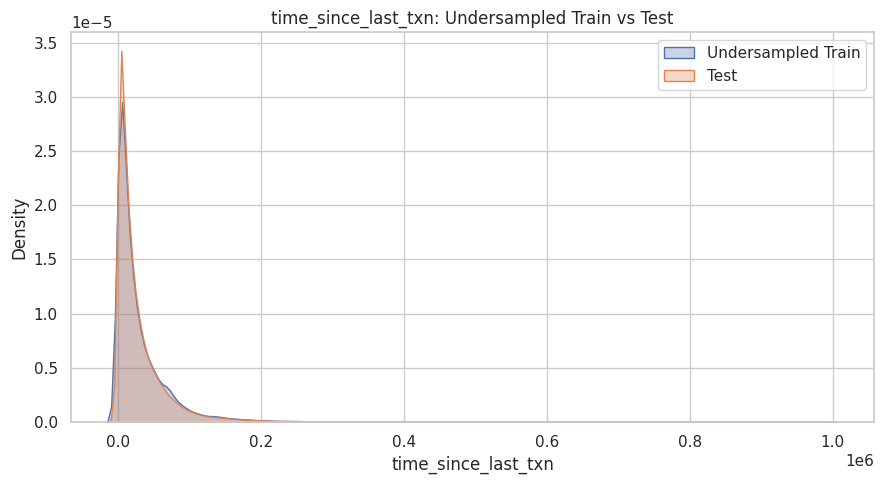


TIME_SINCE_LAST_TXN
                            mean           std  min   median       max
Dataset                                                               
Test                29180.847545  40787.635861  0.0  15418.0  971874.0
Undersampled Train  31227.186142  46103.623670  0.0  15654.0  992166.0


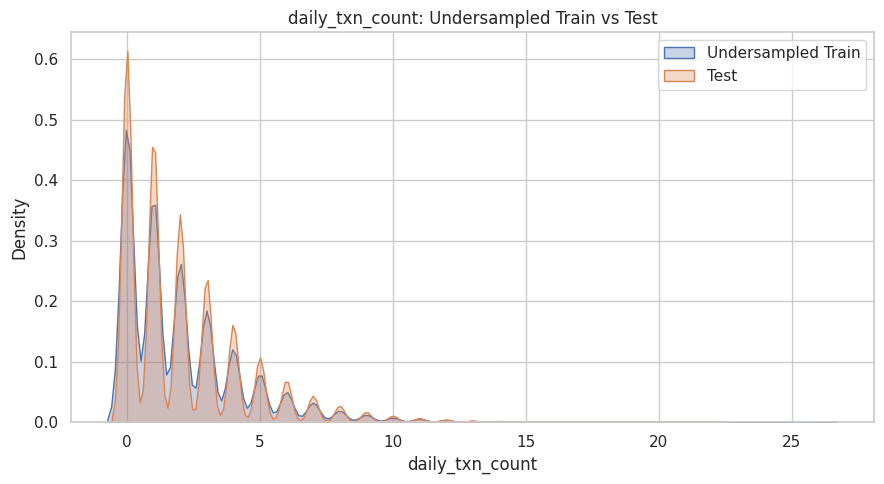


DAILY_TXN_COUNT
                        mean       std  min  median  max
Dataset                                                 
Test                2.098230  2.300502    0     1.0   22
Undersampled Train  2.058208  2.332076    0     1.0   26


In [ ]:
# ==========================================
# UNDERSAMPLED TRAIN VS TEST
# ==========================================

X_train_res_df = pd.DataFrame(
    X_train_res,
    columns=X_train.columns
)

plot_features = [
    "amt",
    "daily_spend_ratio",
    "avg_amt_per_card",
    "time_since_last_txn",
    "daily_txn_count"
]

for feature in plot_features:

    plt.figure(figsize=(9,5))

    sns.kdeplot(
        X_train_res_df[feature],
        label="Undersampled Train",
        fill=True,
        common_norm=False,
        alpha=0.30
    )

    sns.kdeplot(
        X_test[feature],
        label="Test",
        fill=True,
        common_norm=False,
        alpha=0.30
    )

    plt.title(f"{feature}: Undersampled Train vs Test")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()

    plt.tight_layout()
    plt.show()

    summary = pd.concat([
        pd.DataFrame({
            "Dataset":"Undersampled Train",
            "Value":X_train_res_df[feature]
        }),
        pd.DataFrame({
            "Dataset":"Test",
            "Value":X_test[feature]
        })
    ])

    print("\n" + "="*70)
    print(feature.upper())
    print("="*70)

    print(
        summary.groupby("Dataset")["Value"]
        .agg(["mean","std","min","median","max"])
    )